In [17]:
# CELL 1 — CONFIG. The only cell you edit.
CFG = {
    "seed": 1337,

    # smoke = 40 img/class, 1 epoch/stage, no crawl, no export. Run it before any full run.
    "smoke": False,

    # ---------- image / speed ----------
    "img_size": 224,               # model input
    "pre_size": 256,               # preload target; augmentation crops 256 -> 224
    "batch_size_per_replica": 64,  # global batch = this x num_replicas
    "amp": True,                   # mixed_float16
    "jit": False,                  # XLA off by default: MacroF1 uses tf.math.confusion_matrix,
                                   # a possible XLA compile failure, and at ~35 steps/epoch XLA
                                   # saves almost nothing. True to try it on a single GPU.
    "multi_gpu": False,            # single GPU by default: MirroredStrategy adds friction
                                   # (XLA off, batch split) for no accuracy gain. True to try
                                   # both T4s anyway.
    "preload_ram": True,           # pre-decode into a RAM array (the speed win)
    "ram_frac": 0.40,              # preload budget as a fraction of AVAILABLE ram
    "workers": 8,

    # Wall-clock cap on TRAINING ONLY (starts at Cell 14, not at notebook start).
    "train_budget_min": 20,

    # ---------- canonical taxonomy: single source of truth ----------
    # 6 classes, from anshul6 + dedeikh + indo3. Two classes of the original 8 are absent:
    #   Hispa  — only shayanriyaz had it, and that download does not fit (see CFG["sources"]).
    #   Tungro — only indo3 had it, at ~80 images, below min_class.
    # Both are recoverable, but neither is worth blocking on. See README section 3.
    "classes": ["Bacterial_Leaf_Blight", "Brown_Spot", "Healthy",
                "Leaf_Blast", "Leaf_Scald", "Sheath_Blight"],
    # dedeikh also ships "Narrow Brown Spot". At 224px it is not reliably separable from
    # Brown Spot, so by default it folds in and donates its images.
    # Set False AND add "Narrow_Brown_Spot" to "classes" to keep it as its own label.
    "merge_narrow_brown": True,

    # ---------- data sources ----------
    # type "auto"   : Add Input mount first, then a disk-gated CLI download
    # type "local"  : mount only, fail loudly if absent
    # type "kaggle" : CLI download only, still gated on free disk
    #
    # USE "Add Input". Mounted datasets live in /kaggle/input and cost ZERO /kaggle/working
    # space; the CLI path costs 2x the zip size (zip + extracted copy) on a ~20 GB volume.
    # `zip_gb` is only used to preflight the CLI path — measured from Kaggle's dataset
    # metadata, not guessed. Delete a source to drop its classes (see Cell 7 for what happens).
    "allow_cli_download": True,
    "sources": [
        {"name": "anshul6",    "type": "auto", "slug": "anshulm257/rice-disease-dataset",
         "mount": "/kaggle/input/rice-disease-dataset", "zip_gb": 1.1},
        {"name": "dedeikh",    "type": "auto", "slug": "dedeikhsandwisaputra/rice-leafs-disease-dataset",
         "mount": "/kaggle/input/rice-leafs-disease-dataset", "zip_gb": 0.4},
        # shayanriyaz is DISABLED. It is 8.04 GB for 3,355 images and the `kaggle` CLI failed
        # to fetch it three ways (direct, with TMPDIR redirected at WORK, with the zip deleted
        # after extraction) while /kaggle/working still had 19.5 GB free — so the limit is a
        # Kaggle-side quota or CLI staging path we cannot see or size. Its only unique class is
        # Hispa; its author describes it as an aggregation of other web datasets, so much of it
        # probably duplicates anshul6/dedeikh. Enable it only via Add Input (mounted datasets
        # cost no working disk). Re-enable by uncommenting the line and adding
        # "Hispa" to CFG["classes"].
        # {"name": "shayan_cc0", "type": "auto", "slug": "shayanriyaz/riceleafs",
        #  "mount": "/kaggle/input/riceleafs", "zip_gb": 8.1},

        # indo3 IS enabled but contributes little: 240 images across 3 classes, so ~80 per class
        # and ~56 after the train split. That is under min_class, so Cell 7 drops its unique
        # class (Tungro) and keeps only the Brown Spot / Leaf Blast images as extra samples.
        {"name": "indo3",      "type": "auto", "slug": "tedisetiady/leaf-rice-disease-indonesia",
         "mount": "/kaggle/input/leaf-rice-disease-indonesia", "zip_gb": 0.3},
    ],

    # folder name -> canonical class. Keys are matched after stripping non-alphanumerics and
    # lowercasing, so "Leaf Scald", "leaf_scald" and "LeafScald" all hit the same entry.
    #
    # Deliberately ABSENT, because these are guesses that would silently mislabel rather than
    # surface as UNMAPPED for review:
    #   "blight", "brown", "good", "sheath"      -> too generic, could match anything
    #   "bacterialleafspot"                       -> a DIFFERENT disease from leaf blight
    #   "yellowleaf", "leafyellow"                -> not reliably Tungro
    # If one of those appears, Cell 4 lists it under UNMAPPED and you add it deliberately.
    "alias": {
        "bacterialleafblight": "Bacterial_Leaf_Blight",
        "bacterialleaf":       "Bacterial_Leaf_Blight",
        "brownspot":           "Brown_Spot",
        "brownleafspot":       "Brown_Spot",
        "healthy":             "Healthy",
        "healthyriceleaf":     "Healthy",
        "healthyleaf":         "Healthy",
        "normal":              "Healthy",          # standard convention for healthy leaves
        "hispa":               "Hispa",
        "ricehispa":           "Hispa",
        "leafblast":           "Leaf_Blast",
        "blast":               "Leaf_Blast",
        "riceblast":           "Leaf_Blast",
        "leafscald":           "Leaf_Scald",
        "scald":               "Leaf_Scald",
        "sheathblight":        "Sheath_Blight",
        "shb":                 "Sheath_Blight",
        "tungro":              "Tungro",
        "tungrovirus":         "Tungro",
    },

    # ---------- per-source alias overrides ----------
    # Checked BEFORE the global table below. This is how a genuinely ambiguous folder name
    # becomes safe to map: "blight" on its own is untrustworthy — it could mean leaf blight,
    # stem blight or fire blight, which is exactly why it is absent from "alias". But inside
    # indo3 it is unambiguous: that dataset is 240 images in three folders, `leafblast`,
    # `tungro` and `blight`. Two of those three already name themselves, so the third can only
    # be the bacterial disease. Scoping the mapping to the source removes the ambiguity instead
    # of guessing globally.
    "source_alias": {
        "indo3": {"blight": "Bacterial_Leaf_Blight"},
    },

    # ---------- split / dedupe ----------
    "split": {"train": 0.70, "val": 0.15, "test": 0.15},
    # pHash is not flip/rotate invariant, so plain pHash misses exactly the `Rice_Leaf_AUG`
    # siblings we need to group. dihedral=True hashes all 8 D4 variants per image; the
    # distance between two images is the MIN over the 8x8 variant pairs (brute-force numpy).
    # near_dist is the single merge threshold, and ONLY same-class pairs merge (cross-class
    # near-duplicates are label noise -> excluded from val/test in Cell 6).
    "dedupe": {"enable": True, "dihedral": True, "near_dist": 4},
    "min_class": 120,   # MINIMUM TRAIN IMAGES, enforced AFTER the split (see Cell 7)

    # ---------- imbalance ----------
    # class_weight only. effective/oversample were removed on purpose (audit): class_weight
    # is the one that worked, and the others added config surface without a measured win.
    "imbalance": {"mode": "class_weight"},

    # ---------- honest evaluation (Phase 3) ----------
    # The headline metric is source-held-out: train on anshul6+indo3, test on dedeikh across
    # the 5 shared classes (Sheath_Blight is single-source in anshul6, so it stays in training
    # but is excluded from the held-out eval). dedeikh is the noisy source (README section 6),
    # so this is the honest number. Set to None to disable and train on every source.
    "held_out_source": "dedeikh",
    "abstain_threshold": 0.5,   # held-out/field eval: skip predictions below this confidence
    "bootstrap_iters": 2000,    # bootstrap CI for the headline macro-F1

    # ---------- augmentation (CPU, after preload -> never baked into exports) ----------
    # Applied in 0..1, matching tf.image.adjust_* expectations.
    "aug": {"rrc_scale": (0.70, 1.00), "flip_h": True, "flip_v": False,
            "brightness": 0.25, "contrast": 0.25, "sat": 0.15, "hue": 0.03},

    # ---------- progressive unfreezing ----------
    # n > 0 = first n backbone layers, n < 0 = last n, 0 = backbone frozen.
    # Only the BACKBONE is selected here; the head always trains in every stage.
    "stages": [
        {"name": "A_head",    "unfreeze": 0,   "epochs": 4, "lr": 1e-3},
        {"name": "B_shallow", "unfreeze": -18, "epochs": 6, "lr": 1e-4},
        {"name": "C_deep",    "unfreeze": -70, "epochs": 6, "lr": 3e-5},
    ],

    # ---------- crawled web photos: quarantined ----------
    "crawl": {
        "enable": True,
        "role": "stress_test",       # stress_test only (finetune removed on purpose)
        "providers": ["wikimedia", "ddg"],
        "per_class": 20,
        "min_side": 200,
        "max_bytes": 5_000_000,      # per-image download cap (a 20 MB photo is never useful)
        "sleep": 0.3,
        "max_seconds": 180,
        "contact": "gau.mah077@gmail.com",   # crawler User-Agent contact (Wikimedia UA policy)
        "queries": {
            "Brown_Spot": ["rice leaf brown spot disease", "oryza sativa brown spot leaf"],
            "Leaf_Blast": ["rice leaf blast disease", "rice blast lesion leaf field"],
            "Healthy":    ["healthy rice leaf close up", "rice plant leaf green"],
        },
    },

    "export": {"tflite": True},
}

if not CFG["merge_narrow_brown"] and "Narrow_Brown_Spot" not in CFG["classes"]:
    raise SystemExit("merge_narrow_brown=False requires 'Narrow_Brown_Spot' in CFG['classes']")


In [18]:
# CELL 2 — MODULE. Generated from agrisense.py by split_cells.py. Do not hand-edit.
"""Agrisense — rice leaf disease pipeline (single module).

The Kaggle notebook is a thin 3-cell wrapper: CONFIG -> MODULE -> RUN. This module holds
all the logic. PIPELINE_VERSION is printed by every entry point (run, train, export, bundle)
so a stale paste is visible in the log instead of silently shipping.

The notebook's MODULE cell is generated from this file by `split_cells.py` (the
`# %% include:agrisense.py` directive). Do not hand-edit the generated cell.
"""

# ---- environment setup (must precede the tensorflow import) ----
import os
import sys
import time
import shutil
import tempfile
import subprocess
from pathlib import Path

# NOTE: PYTHONHASHSEED is read by the interpreter at startup, so setting it here is a no-op.
# It is set only because Kaggle lets you control it from the environment panel. Nothing in
# this pipeline depends on it (all seeding is explicit).
os.environ.setdefault("PYTHONHASHSEED", "1337")
_NC = max(1, os.cpu_count() or 4)
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")   # hides the absl/CUDA banner noise
os.environ.setdefault("TF_NUM_INTRAOP_THREADS", str(min(8, _NC)))
os.environ.setdefault("TF_NUM_INTEROP_THREADS", "2")

# ---- imports (Kaggle preinstalls; imagehash/ddgs are pip-installed in deps()) ----
import importlib.util
import random
import re
import json
import zipfile
import io
import contextlib
import gc
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
import tensorflow.keras.callbacks as KC     # KC, not K — K is used as a class count in Cell 8

# Bumped on every intentional pipeline change. Printed at every entry point (start, train,
# export, bundle) so a stale paste is visible in the log instead of silently shipping.
PIPELINE_VERSION = "3.1.2"


# =====================================================================================
# DEFAULT_CFG — the same dict the notebook's CONFIG cell starts from. The notebook cell
# is the editable copy; verify.py AST-compares the two so they cannot drift.
# =====================================================================================
DEFAULT_CFG = {
    "seed": 1337,

    # smoke = 40 img/class, 1 epoch/stage, no crawl, no export. Run it before any full run.
    "smoke": False,

    # ---------- image / speed ----------
    "img_size": 224,               # model input
    "pre_size": 256,               # preload target; augmentation crops 256 -> 224
    "batch_size_per_replica": 64,  # global batch = this x num_replicas
    "amp": True,                   # mixed_float16
    "jit": False,                  # XLA off by default: MacroF1 uses tf.math.confusion_matrix,
                                   # a possible XLA compile failure, and at ~35 steps/epoch XLA
                                   # saves almost nothing. True to try it on a single GPU.
    "multi_gpu": False,            # single GPU by default: MirroredStrategy adds friction
                                   # (XLA off, batch split) for no accuracy gain. True to try
                                   # both T4s anyway.
    "preload_ram": True,           # pre-decode into a RAM array (the speed win)
    "ram_frac": 0.40,              # preload budget as a fraction of AVAILABLE ram
    "workers": 8,

    # Wall-clock cap on TRAINING ONLY (starts at Cell 14, not at notebook start).
    "train_budget_min": 20,

    # ---------- canonical taxonomy: single source of truth ----------
    # 6 classes, from anshul6 + dedeikh + indo3. Two classes of the original 8 are absent:
    #   Hispa  — only shayanriyaz had it, and that download does not fit (see CFG["sources"]).
    #   Tungro — only indo3 had it, at ~80 images, below min_class.
    # Both are recoverable, but neither is worth blocking on. See README section 3.
    "classes": ["Bacterial_Leaf_Blight", "Brown_Spot", "Healthy",
                "Leaf_Blast", "Leaf_Scald", "Sheath_Blight"],
    # dedeikh also ships "Narrow Brown Spot". At 224px it is not reliably separable from
    # Brown Spot, so by default it folds in and donates its images.
    # Set False AND add "Narrow_Brown_Spot" to "classes" to keep it as its own label.
    "merge_narrow_brown": True,

    # ---------- data sources ----------
    # type "auto"   : Add Input mount first, then a disk-gated CLI download
    # type "local"  : mount only, fail loudly if absent
    # type "kaggle" : CLI download only, still gated on free disk
    #
    # USE "Add Input". Mounted datasets live in /kaggle/input and cost ZERO /kaggle/working
    # space; the CLI path costs 2x the zip size (zip + extracted copy) on a ~20 GB volume.
    # `zip_gb` is only used to preflight the CLI path — measured from Kaggle's dataset
    # metadata, not guessed. Delete a source to drop its classes (see Cell 7 for what happens).
    "allow_cli_download": True,
    "sources": [
        {"name": "anshul6",    "type": "auto", "slug": "anshulm257/rice-disease-dataset",
         "mount": "/kaggle/input/rice-disease-dataset", "zip_gb": 1.1},
        {"name": "dedeikh",    "type": "auto", "slug": "dedeikhsandwisaputra/rice-leafs-disease-dataset",
         "mount": "/kaggle/input/rice-leafs-disease-dataset", "zip_gb": 0.4},
        # shayanriyaz is DISABLED. It is 8.04 GB for 3,355 images and the `kaggle` CLI failed
        # to fetch it three ways (direct, with TMPDIR redirected at WORK, with the zip deleted
        # after extraction) while /kaggle/working still had 19.5 GB free — so the limit is a
        # Kaggle-side quota or CLI staging path we cannot see or size. Its only unique class is
        # Hispa; its author describes it as an aggregation of other web datasets, so much of it
        # probably duplicates anshul6/dedeikh. Enable it only via Add Input (mounted datasets
        # cost no working disk). Re-enable by uncommenting the line and adding
        # "Hispa" to CFG["classes"].
        # {"name": "shayan_cc0", "type": "auto", "slug": "shayanriyaz/riceleafs",
        #  "mount": "/kaggle/input/riceleafs", "zip_gb": 8.1},

        # indo3 IS enabled but contributes little: 240 images across 3 classes, so ~80 per class
        # and ~56 after the train split. That is under min_class, so Cell 7 drops its unique
        # class (Tungro) and keeps only the Brown Spot / Leaf Blast images as extra samples.
        {"name": "indo3",      "type": "auto", "slug": "tedisetiady/leaf-rice-disease-indonesia",
         "mount": "/kaggle/input/leaf-rice-disease-indonesia", "zip_gb": 0.3},
    ],

    # folder name -> canonical class. Keys are matched after stripping non-alphanumerics and
    # lowercasing, so "Leaf Scald", "leaf_scald" and "LeafScald" all hit the same entry.
    #
    # Deliberately ABSENT, because these are guesses that would silently mislabel rather than
    # surface as UNMAPPED for review:
    #   "blight", "brown", "good", "sheath"      -> too generic, could match anything
    #   "bacterialleafspot"                       -> a DIFFERENT disease from leaf blight
    #   "yellowleaf", "leafyellow"                -> not reliably Tungro
    # If one of those appears, Cell 4 lists it under UNMAPPED and you add it deliberately.
    "alias": {
        "bacterialleafblight": "Bacterial_Leaf_Blight",
        "bacterialleaf":       "Bacterial_Leaf_Blight",
        "brownspot":           "Brown_Spot",
        "brownleafspot":       "Brown_Spot",
        "healthy":             "Healthy",
        "healthyriceleaf":     "Healthy",
        "healthyleaf":         "Healthy",
        "normal":              "Healthy",          # standard convention for healthy leaves
        "hispa":               "Hispa",
        "ricehispa":           "Hispa",
        "leafblast":           "Leaf_Blast",
        "blast":               "Leaf_Blast",
        "riceblast":           "Leaf_Blast",
        "leafscald":           "Leaf_Scald",
        "scald":               "Leaf_Scald",
        "sheathblight":        "Sheath_Blight",
        "shb":                 "Sheath_Blight",
        "tungro":              "Tungro",
        "tungrovirus":         "Tungro",
    },

    # ---------- per-source alias overrides ----------
    # Checked BEFORE the global table below. This is how a genuinely ambiguous folder name
    # becomes safe to map: "blight" on its own is untrustworthy — it could mean leaf blight,
    # stem blight or fire blight, which is exactly why it is absent from "alias". But inside
    # indo3 it is unambiguous: that dataset is 240 images in three folders, `leafblast`,
    # `tungro` and `blight`. Two of those three already name themselves, so the third can only
    # be the bacterial disease. Scoping the mapping to the source removes the ambiguity instead
    # of guessing globally.
    "source_alias": {
        "indo3": {"blight": "Bacterial_Leaf_Blight"},
    },

    # ---------- split / dedupe ----------
    "split": {"train": 0.70, "val": 0.15, "test": 0.15},
    # pHash is not flip/rotate invariant, so plain pHash misses exactly the `Rice_Leaf_AUG`
    # siblings we need to group. dihedral=True hashes all 8 D4 variants per image; the
    # distance between two images is the MIN over the 8x8 variant pairs (brute-force numpy).
    # near_dist is the single merge threshold, and ONLY same-class pairs merge (cross-class
    # near-duplicates are label noise -> excluded from val/test in Cell 6).
    "dedupe": {"enable": True, "dihedral": True, "near_dist": 4},
    "min_class": 120,   # MINIMUM TRAIN IMAGES, enforced AFTER the split (see Cell 7)

    # ---------- imbalance ----------
    # class_weight only. effective/oversample were removed on purpose (audit): class_weight
    # is the one that worked, and the others added config surface without a measured win.
    "imbalance": {"mode": "class_weight"},

    # ---------- honest evaluation (Phase 3) ----------
    # The headline metric is source-held-out: train on anshul6+indo3, test on dedeikh across
    # the 5 shared classes (Sheath_Blight is single-source in anshul6, so it stays in training
    # but is excluded from the held-out eval). dedeikh is the noisy source (README section 6),
    # so this is the honest number. Set to None to disable and train on every source.
    "held_out_source": "dedeikh",
    "abstain_threshold": 0.5,   # held-out/field eval: skip predictions below this confidence
    "bootstrap_iters": 2000,    # bootstrap CI for the headline macro-F1

    # ---------- augmentation (CPU, after preload -> never baked into exports) ----------
    # Applied in 0..1, matching tf.image.adjust_* expectations.
    "aug": {"rrc_scale": (0.70, 1.00), "flip_h": True, "flip_v": False,
            "brightness": 0.25, "contrast": 0.25, "sat": 0.15, "hue": 0.03},

    # ---------- progressive unfreezing ----------
    # n > 0 = first n backbone layers, n < 0 = last n, 0 = backbone frozen.
    # Only the BACKBONE is selected here; the head always trains in every stage.
    "stages": [
        {"name": "A_head",    "unfreeze": 0,   "epochs": 4, "lr": 1e-3},
        {"name": "B_shallow", "unfreeze": -18, "epochs": 6, "lr": 1e-4},
        {"name": "C_deep",    "unfreeze": -70, "epochs": 6, "lr": 3e-5},
    ],

    # ---------- crawled web photos: quarantined ----------
    "crawl": {
        "enable": True,
        "role": "stress_test",       # stress_test only (finetune removed on purpose)
        "providers": ["wikimedia", "ddg"],
        "per_class": 20,
        "min_side": 200,
        "max_bytes": 5_000_000,      # per-image download cap (a 20 MB photo is never useful)
        "sleep": 0.3,
        "max_seconds": 180,
        "contact": "gau.mah077@gmail.com",   # crawler User-Agent contact (Wikimedia UA policy)
        "queries": {
            "Brown_Spot": ["rice leaf brown spot disease", "oryza sativa brown spot leaf"],
            "Leaf_Blast": ["rice leaf blast disease", "rice blast lesion leaf field"],
            "Healthy":    ["healthy rice leaf close up", "rice plant leaf green"],
        },
    },

    "export": {"tflite": True},
}

if not DEFAULT_CFG["merge_narrow_brown"] and "Narrow_Brown_Spot" not in DEFAULT_CFG["classes"]:
    raise SystemExit("merge_narrow_brown=False requires 'Narrow_Brown_Spot' in CFG['classes']")


# =====================================================================================
# Module-level helpers (no instance state)
# =====================================================================================
def _pip(*pkgs, required=True):
    # Each arg is (import_name, install_spec). The import name is what we probe; the spec is
    # what pip installs, and it is PINNED so a future package release cannot silently change
    # the pipeline. "PIL" is the import name of "Pillow" — pip has no package called "PIL".
    missing = [s for s in pkgs if importlib.util.find_spec(s[0]) is None]
    if not missing:
        print(f"present: {' '.join(s[0] for s in pkgs)}"); return
    names = [s[1] for s in missing]
    print(f"installing: {' '.join(names)} (import name(s): {' '.join(s[0] for s in missing)})")
    try:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *names], check=True)
        # pip returning 0 is not proof: the install can land yet the module still not import
        # (stale sys.path cache, or a shadowing local file). Re-probe before claiming OK.
        importlib.invalidate_caches()
        for imp, _ in missing:
            if importlib.util.find_spec(imp) is None:
                raise ImportError(f"{imp} still not importable after installing {' '.join(names)}")
        print("  installed and importable")
    except Exception as e:
        if required: raise
        print(f"  optional install failed ({type(e).__name__}) — continuing without it")


def norm(s):
    return re.sub(r"[^a-z0-9]", "", str(s).lower())


# =====================================================================================
# Keras metric + callbacks (module-level: Keras serialization / callback lifecycle)
# =====================================================================================
@tf.keras.utils.register_keras_serializable(package="agrisense")
class MacroF1(tf.keras.metrics.Metric):
    # result() is traced into the compiled graph, so it must be pure TF ops — numpy here fails.
    # get_config is required for the metric to survive model.save / load_model.
    def __init__(self, k, name="macro_f1", dtype=None, **kw):
        super().__init__(name=name, dtype=dtype, **kw)
        self.k = int(k)
        self.cm = self.add_weight(shape=(int(k), int(k)), initializer="zeros",
                                  dtype=tf.float32, name="confusion")

    def update_state(self, y_true, y_pred, sample_weight=None):
        m = tf.math.confusion_matrix(tf.argmax(y_true, -1), tf.argmax(y_pred, -1),
                                     num_classes=self.k, dtype=tf.float32)
        self.cm.assign_add(m)

    def result(self):
        cm = tf.cast(self.cm, tf.float32)
        tp = tf.linalg.diag_part(cm)
        prec = tf.math.divide_no_nan(tp, tf.reduce_sum(cm, axis=0))
        rec  = tf.math.divide_no_nan(tp, tf.reduce_sum(cm, axis=1))
        return tf.reduce_mean(tf.math.divide_no_nan(2 * prec * rec, prec + rec))

    def reset_state(self):
        self.cm.assign(tf.zeros_like(self.cm))

    def get_config(self):
        c = super().get_config(); c["k"] = self.k; return c


class SaveBestF1(KC.Callback):
    # ONE global best, written to ONE file. `best` is a CLASS attribute on purpose: each
    # stage creates a fresh callback, and a per-instance best would reset to -1 every stage
    # (Stage C would always save its first epoch regardless of F1).
    best = -1.0

    def __init__(self, best_path):
        super().__init__()
        self.best_path = best_path

    def on_epoch_end(self, epoch, logs=None):
        f1 = logs.get("val_macro_f1", -1.0)
        if f1 > SaveBestF1.best:
            SaveBestF1.best = f1
            self.model.save(self.best_path)
            print(f"  ** saved best.keras (val_macro_f1={f1:.4f})")


class BudgetStop(KC.Callback):
    # Caps TRAINING only. T_TRAIN0 is set in train(), not at pipeline start, so downloads,
    # grouping and preloading do not eat the budget.
    def __init__(self, t_train0, budget_min):
        super().__init__()
        self.t_train0 = t_train0
        self.budget_min = budget_min

    def on_epoch_begin(self, epoch, logs=None):
        if (time.time() - self.t_train0) / 60.0 > self.budget_min:
            self.model.stop_training = True
            print(f"!! training budget {self.budget_min} min hit -> stopping")


# =====================================================================================
# Pipeline — one method per notebook cell. Shared state lives on `self`.
# =====================================================================================
class Pipeline:
    def __init__(self, cfg):
        self.cfg = cfg
        self.T0 = time.time()
        self.KAGGLE = Path("/kaggle").is_dir()
        self.WORK = Path("/kaggle/working") if self.KAGGLE else Path(tempfile.gettempdir()) / "agrisense"
        self.WORK.mkdir(parents=True, exist_ok=True)

    # ---- environment helpers (Cell 0) ----
    def _ram_gb(self):
        """Cross-platform RAM probe. Never raises — a diagnostic must not be able to kill a run."""
        try:
            import psutil
            v = psutil.virtual_memory(); return v.total / 1e9, v.available / 1e9
        except Exception:
            pass
        try:
            d = {l.split(":")[0].strip(): int(l.split()[1])
                 for l in open("/proc/meminfo") if ":" in l}
            return d["MemTotal"] / 1e6, d["MemAvailable"] / 1e6
        except Exception:
            return float("nan"), float("nan")

    def _free_gb(self, p=None):
        """Free bytes on the filesystem holding WORK, in GB. Never raises.

        Disk headroom is the binding constraint on Kaggle: /kaggle/working is ~20 GB and one
        source (shayanriyaz) is an 8 GB zip that expands to another 8 GB. Every download in
        fetch() is therefore gated on this number."""
        try:
            return shutil.disk_usage(p or self.WORK).free / 1e9
        except Exception:
            return float("nan")

    def _tmp_gb(self):
        """Free space on the system temp dir.

        Reported separately because it is the resource that actually failed: the `kaggle` CLI
        stages its download through temp, and on Kaggle /tmp is a much smaller filesystem than
        /kaggle/working. fetch() now redirects TMPDIR at WORK so the two agree — but the sizes
        are worth seeing, because "19.5 GB free on /kaggle/working" coexisting with Errno 28 on
        an 8 GB download is otherwise a mystery."""
        for cand in (tempfile.gettempdir(), "/tmp"):
            try:
                g = shutil.disk_usage(cand).free / 1e9
                return f"{g:.1f} GB free on {tempfile.gettempdir()}"
            except Exception:
                continue
        return "temp space unknown"

    def _dir_gb(self, d):
        """Recursive on-disk size of a tree, in GB. Used to report what we just freed."""
        try:
            return sum(f.stat().st_size for f in Path(d).rglob("*") if f.is_file()) / 1e9
        except Exception:
            return 0.0

    def _vram_lines(self):
        """Per-GPU total/used VRAM in MB, via nvidia-smi. Empty list if unavailable."""
        try:
            r = subprocess.run(["nvidia-smi",
                                "--query-gpu=index,name,memory.total,memory.used",
                                "--format=csv,noheader,nounits"],
                               capture_output=True, text=True, timeout=20)
            if r.returncode == 0:
                return [ln.strip() for ln in r.stdout.strip().splitlines() if ln.strip()]
        except Exception:
            pass
        return []

    def elapsed(self):
        return (time.time() - self.T0) / 60.0

    # ---- CELL 0 — environment probe ----
    # Laptop-safe on purpose: no hard exit, no Kaggle-only paths. You can dry-run this on your
    # machine to sanity-check imports. It will refuse to *train* without a GPU, not refuse to start.
    def env(self):
        self.RAM_GB, self.RAM_AVAIL_GB = self._ram_gb()
        free_gb = self._free_gb()
        print(f"PIPELINE_VERSION {PIPELINE_VERSION} | python {sys.version.split()[0]} | cpus {_NC} | "
              f"platform {'kaggle' if self.KAGGLE else 'local'}")
        print(f"tf {tf.__version__} | numpy {np.__version__} | keras {tf.keras.__version__}")
        print(f"RAM {self.RAM_GB:.1f} GB total / {self.RAM_AVAIL_GB:.1f} GB available | "
              f"disk {free_gb:.1f} GB free in WORK")
        print(f"temp: {self._tmp_gb()} (fetch() redirects TMPDIR here, so WORK is the only limit)")
        print(f"work dir: {self.WORK}")

        self.gpus = tf.config.list_physical_devices("GPU")
        # Best-effort memory growth. One effect that matters here: it stops TF pre-allocating
        # all 13.7 GB per T4, which is what turns a late allocation into "OOM at the last
        # epoch" instead of a clean failure. Must run before any GPU op; if it fails we carry on.
        for g in self.gpus:
            try:
                tf.config.experimental.set_memory_growth(g, True)
            except Exception as e:
                print(f"  set_memory_growth({g.name}) refused: {type(e).__name__}")

        _vram = self._vram_lines()
        if _vram:
            for ln in _vram:
                parts = [p.strip() for p in ln.split(",")]
                # Never let a display probe kill the run: a GPU name containing a comma, or a
                # driver that changes the column set, must degrade to a printed line, not an
                # exception.
                try:
                    idx, name, total, used = parts
                    print(f"  GPU {idx}: {name}  VRAM {int(total)/1024:.1f} GB total / "
                          f"{int(used)/1024:.2f} GB used")
                except Exception:
                    print(f"  GPU (unparsed nvidia-smi line): {ln}")
        else:
            print("  (nvidia-smi unavailable — VRAM figures omitted, training unaffected)")
        print(f"GPUs detected: {len(self.gpus)}")
        if not self.gpus:
            print("!! No GPU. Stages 0-9 still run; train() will be very slow or fail.")
            print("!! On Kaggle: Settings -> Accelerator -> GPU T4 x2 -> Save.")
        print(f"disk headroom: {self._free_gb():.1f} GB")

    # ---- CELL 2 — deps, imports, seeds, strategy ----
    # imagehash and ddgs are NOT Kaggle preinstalls.
    def deps(self):
        # Pinned: imagehash and ddgs are the two packages this pipeline actually installs on
        # Kaggle. Pillow is a Kaggle preinstall, so it is left unpinned (only installed if missing).
        _pip(("PIL", "Pillow"), ("imagehash", "imagehash==4.3.2"))
        try:
            _pip(("ddgs", "ddgs==9.16.0"), required=False)   # DuckDuckGo image search, crawler only
        except Exception:
            pass

        SEED = self.cfg["seed"]
        random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
        self.AUTOTUNE = tf.data.AUTOTUNE
        self.SIZE, self.PRE = self.cfg["img_size"], self.cfg["pre_size"]
        self.OUT = self.WORK / "out"; self.OUT.mkdir(exist_ok=True)
        self.IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff", ".jfif"}

        if self.cfg["amp"]:
            tf.keras.mixed_precision.set_global_policy("mixed_float16")

        self.STRATEGY = None
        if self.cfg["multi_gpu"] and len(self.gpus) > 1:
            try:
                self.STRATEGY = tf.distribute.MirroredStrategy()
            except Exception as e:
                print(f"MirroredStrategy unavailable ({type(e).__name__}: {str(e)[:60]}) -> single GPU")
        REPLICAS = self.STRATEGY.num_replicas_in_sync if self.STRATEGY is not None else 1
        PER_REP  = self.cfg["batch_size_per_replica"]
        self.BS  = PER_REP * REPLICAS
        self.JIT = bool(self.cfg["jit"]) and self.STRATEGY is None   # XLA + MirroredStrategy has friction
        print(f"replicas {REPLICAS} | global batch {self.BS} ({PER_REP}/replica) | XLA {self.JIT}")

        self.CLASSES = list(self.cfg["classes"])
        if len(set(self.CLASSES)) != len(self.CLASSES):
            dupes = sorted({c for c in self.CLASSES if self.CLASSES.count(c) > 1})
            raise SystemExit(f"CFG['classes'] has duplicates: {dupes}")
        self.CIDX = {c: i for i, c in enumerate(self.CLASSES)}
        self.NC = len(self.CLASSES)          # class count. Never shadow the KC module or any other name.

        self.ALIAS = self.build_alias()
        self.SRC_ALIAS = {}
        for _src, _m in self.cfg.get("source_alias", {}).items():
            _d = {norm(k): v for k, v in _m.items()}
            _orph = {k: v for k, v in _d.items() if v not in self.CIDX}
            if _orph:
                print(f"!! dropping {len(_orph)} source_alias entr(y/ies) for {_src} whose class is "
                      f"not in CFG['classes']: {sorted(set(_orph.values()))}")
                _d = {k: v for k, v in _d.items() if v in self.CIDX}
            self.SRC_ALIAS[_src] = _d
        for _src, _d in self.SRC_ALIAS.items():
            print(f"source_alias[{_src}]: {_d or 'empty'}")

        print(f"taxonomy ({self.NC}): {self.CLASSES}")
        print(f"alias: {len(self.ALIAS)} folder patterns -> {sorted(set(self.ALIAS.values()))}")
        print(f"narrow brown spot -> {'Brown_Spot (merged)' if self.cfg['merge_narrow_brown'] else 'its own label'}")
        # Cross-check: nothing may map to a class that is not declared, and every declared class
        # that has an alias must be reachable. Cheap, and it is the exact bug that shipped last time.
        assert set(self.ALIAS.values()) <= set(self.CLASSES), "alias leaked an undeclared class"
        for _d in self.SRC_ALIAS.values():
            assert set(_d.values()) <= set(self.CLASSES), "source_alias leaked an undeclared class"
        # A source_alias that shadows a global alias with a DIFFERENT class is almost always a
        # typo, and it would silently win in manifest(). Catch it here instead of in a confusion
        # matrix.
        for _src, _d in self.SRC_ALIAS.items():
            for _k, _v in _d.items():
                if _k in self.ALIAS and self.ALIAS[_k] != _v:
                    raise SystemExit(f"source_alias[{_src}]['{_k}'] -> {_v} shadows the global alias "
                                     f"-> {self.ALIAS[_k]}. Remove one of them.")

    def build_alias(self):
        a = {norm(k): v for k, v in self.cfg["alias"].items()}
        # narrow brown spot is handled here so merge_narrow_brown is actually wired up
        a["narrowbrownspot"] = "Brown_Spot" if self.cfg["merge_narrow_brown"] else "Narrow_Brown_Spot"

        # An alias pointing at an undeclared class is a trap. manifest() would label those
        # images with a name that is not in CIDX, and the KeyError only surfaces in
        # class_weights()/preload() — far from the cause. This is the same class of bug as the
        # old `return name.title()` fallback, so it is caught here, loudly, instead of downstream.
        orphans = {v: k for k, v in a.items() if v not in self.CIDX}
        if orphans:
            print(f"!! dropping {len(orphans)} alias entr(y/ies) whose class is not in "
                  f"CFG['classes']: {sorted(set(orphans))}")
            print("   any images in those folders will be reported as UNMAPPED in manifest(), not "
                  "mislabelled. To keep them, add the class name to CFG['classes'].")
            a = {k: v for k, v in a.items() if v in self.CIDX}
        return a

    # ---- CELL 3 — fetch sources ----
    # Resolution order for type "auto":
    #   1. the explicit `mount` path            -> free, costs no /kaggle/working space
    #   2. any /kaggle/input dir matching the slug tail
    #   3. `kaggle datasets download`, GATED on free disk
    #
    # Why the gate exists: /kaggle/working is ~20 GB and shayanriyaz is an 8.1 GB zip that
    # expands to another ~8 GB. Without the gate the download fills the volume, the partial file
    # is left behind, and every later stage dies with Errno 28 — including a 3 KB CSV write.
    # A mounted dataset has none of that cost, so Add Input is always the better path here.
    def _n_images(self, d):
        return sum(1 for _ in Path(d).rglob("*") if _.suffix.lower() in self.IMG_EXT)

    def _first_images(self, d):
        """Walk down to the first directory that actually holds images.
        We deliberately return the SOURCE ROOT, not the image dir: manifest() resolves classes
        from each file's ancestor chain relative to this root, which works for any nesting depth."""
        d = Path(d)
        if not d.is_dir(): return d
        if self._n_images(d): return d
        for c in sorted(d.iterdir()):
            if c.is_dir() and self._n_images(c): return c
        return d

    def _mounted(self, slug):
        """Find an Add Input mount whose directory name matches the slug tail.
        Kaggle's layout varies: /input/<slug> or /input/datasets/<owner>/<slug>, so
        search a few depths instead of assuming one level."""
        want = slug.split("/")[-1].lower()
        base = Path("/kaggle/input")
        if not base.is_dir(): return None
        for pat in ("*", "*/*", "*/*/*"):
            for d in sorted(base.glob(pat)):
                if d.is_dir() and want in d.name.lower():
                    n = self._n_images(d)
                    if n:
                        print(f"   Add Input mount '{d}' ({n} imgs)")
                        return self._first_images(d)
        return None

    def _cli_download(self, src):
        """Download + extract one slug. Returns the extraction root.

        Three deliberate choices, each a fix for a failure we actually hit:
          * PREFLIGHT — refuse before writing anything if the zip plus its expansion cannot fit;
          * DELETE THE ZIP — peak usage is zip + extracted, so removing the zip right after
            extraction halves peak disk. The old code left the zip sitting next to the copy;
          * CLEAN UP ON FAILURE — remove the partial tree, so one bad download cannot make every
            subsequent stage fail with Errno 28."""
        slug = src["slug"]
        out = self.WORK / ("_dl_" + slug.split("/")[-1])
        if (out / "_ok").exists():
            return self._first_images(out / "x")

        if not self.cfg.get("allow_cli_download", True):
            raise RuntimeError("CLI download disabled (CFG['allow_cli_download'] = False)")
        zip_gb = float(src.get("zip_gb") or 0.0)
        # Peak = zip on disk + extracted tree. JPEGs barely recompress, so extracted ~= zip.
        need = zip_gb * 2 + 0.5
        have = self._free_gb()
        if zip_gb and have < need:
            raise RuntimeError(
                f"refusing to download {zip_gb:.1f} GB into {have:.1f} GB free "
                f"(needs ~{need:.1f} GB for zip + extraction).\n"
                f"  FIX (best): Add Input -> attach '{slug.split('/')[-1]}'. Mounted datasets cost\n"
                f"       no /kaggle/working space at all, and fetch() detects it automatically.\n"
                f"  ALTERNATIVELY: drop this source from CFG['sources'] — check min_class() for\n"
                f"       which classes it was the only source for (here: Hispa).")

        # Force the CLI to stage through WORK, not the system temp dir. On Kaggle /tmp is a much
        # smaller filesystem than /kaggle/working, and the kaggle client downloads through a temp
        # file — which is why an 8 GB dataset failed with Errno 28 while WORK still had 19.5 GB
        # free. Pointing TMPDIR/TMP/TEMP at WORK makes the preflight above meaningful.
        staging = self.WORK / "_tmp"
        staging.mkdir(parents=True, exist_ok=True)
        env = dict(os.environ)
        env.update({"TMPDIR": str(staging), "TMP": str(staging), "TEMP": str(staging)})

        try:
            out.mkdir(parents=True, exist_ok=True)
            r = subprocess.run(["kaggle", "datasets", "download", "-d", slug,
                                "-p", str(out), "-q"], capture_output=True, text=True, env=env)
            if r.returncode:
                raise RuntimeError((r.stderr or r.stdout or "").strip()[:200])

            zips = list(out.glob("*.zip"))
            if not zips:
                raise RuntimeError("download reported success but produced no .zip")
            (out / "x").mkdir(parents=True, exist_ok=True)
            for z in zips:
                with zipfile.ZipFile(z) as zf:
                    zf.extractall(out / "x")
                z.unlink()                       # <-- halves peak disk; the only copy left is the tree
            (out / "_ok").write_text("ok")
            return self._first_images(out / "x")
        except OSError as e:
            shutil.rmtree(out, ignore_errors=True)
            # An OSError from the CLI arrives as a bare "[Errno 28] No space left on device",
            # which reads like the working volume is full. It is not: /kaggle/working still has
            # free space, so the CLI is writing somewhere we cannot see or size. Say so.
            raise RuntimeError(
                f"{type(e).__name__} raised while running the kaggle CLI: {e}\n"
                f"  NOT the working volume: /kaggle/working still has {self._free_gb():.1f} GB free,\n"
                f"  and TMPDIR was already redirected at it. The limit is a Kaggle-side quota or a\n"
                f"  CLI staging path outside our control.\n"
                f"  FIX: attach '{slug.split('/')[-1]}' via Add Input. A mounted dataset costs zero\n"
                f"  working disk and bypasses the CLI entirely — fetch() finds it automatically.\n"
                f"  ALTERNATIVELY: remove this source from CFG['sources'] to proceed without it.")
        except Exception:
            shutil.rmtree(out, ignore_errors=True)   # never leave a half-written tree behind
            raise
        finally:
            shutil.rmtree(staging, ignore_errors=True)

    def _fetch_one(self, src):
        kind = src.get("type", "auto")
        slug = src.get("slug")

        if kind in ("local", "auto") and src.get("mount"):
            p = Path(src["mount"])
            if p.is_dir() and self._n_images(p):
                print(f"   mount '{p}' ({self._n_images(p)} imgs)")
                return self._first_images(p)
            if kind == "local":
                raise FileNotFoundError(
                    f"{p} not found — add it via Kaggle 'Add Input', or set type 'auto'/'kaggle'")

        if not slug:
            raise RuntimeError(f"source {src.get('name')} has neither 'mount' nor 'slug'")
        m = self._mounted(slug)
        if m is not None:
            return m
        if kind == "local":
            raise FileNotFoundError(f"no mount for '{slug}' — attach it via Kaggle 'Add Input'")
        return self._cli_download(src)

    def fetch(self):
        self.ROOTS, self.FAILED = [], []
        for s in self.cfg["sources"]:
            t = time.time()
            try:
                r = self._fetch_one(s)
                self.ROOTS.append({**s, "path": r})
                how = "mount" if "/kaggle/input" in str(r) else "cli"
                print(f"[ok]   {s['name']:11s} {self._n_images(r):6d} imgs  [{how}]  {r}  "
                      f"({time.time()-t:.0f}s)")
            except Exception as e:
                self.FAILED.append(s["name"]); print(f"[FAIL] {s['name']:11s} {e}")
        assert self.ROOTS, "no datasets available — check CFG['sources'], Add Input, and Internet"

        left = self._free_gb()
        print(f"\n{len(self.ROOTS)} source(s) ready; failed: {self.FAILED or 'none'}")
        print(f"disk left: {left:.1f} GB")
        # Catch the state that produced Errno 28 in manifest() BEFORE it happens, while we still
        # know which download caused it and can still suggest Add Input instead of a full restart.
        if left < 1.0:
            which = [s["name"] for s in self.ROOTS if "/kaggle/input" not in str(s["path"])]
            raise SystemExit(
                f"only {left:.1f} GB free on /kaggle/working — later stages will fail with Errno 28.\n"
                f"  CLI-downloaded sources: {which or 'none'}\n"
                f"  FIX: attach those via Kaggle 'Add Input' (free), or remove them from CFG['sources'].\n"
                f"  Then restart the session to clear the partial downloads.")

    # ---- CELL 4 — manifest ----
    # Class comes from the NEAREST ancestor folder that hits an alias. Works for
    # Rice_Leaf_AUG/<Class>/, train/<Class>/, validation/<Class>/, and arbitrary nesting.
    #
    # Resolution order per folder, first hit wins:
    #   1. SRC_ALIAS[source]  — per-source overrides, for names only safe in context
    #   2. ALIAS              — the global table
    # Unresolvable images are REPORTED under UNMAPPED, never given an invented label.
    def manifest(self):
        rows, unmapped = [], defaultdict(int)
        via_counts = defaultdict(int)

        for r in self.ROOTS:
            root = r["path"]
            sal = self.SRC_ALIAS.get(r["name"], {})

            for f in Path(root).rglob("*"):
                if not (f.is_file() and f.suffix.lower() in self.IMG_EXT): continue
                parts = f.relative_to(root).parts[:-1]
                cls = via = None
                for d in reversed(parts):
                    k = norm(d)
                    if k in sal:
                        cls, via = sal[k], f"source_alias[{r['name']}]"
                        break
                    if k in self.ALIAS:
                        cls, via = self.ALIAS[k], "alias"
                        break
                if cls is None:
                    unmapped[f"{r['name']}:{'/'.join(parts) or '<root>'}"] += 1
                else:
                    rows.append({"path": str(f), "class": cls, "source": r["name"], "via": via})
                    via_counts[via] += 1

        self.man = pd.DataFrame(rows)
        if self.man.empty:
            raise SystemExit("manifest empty — CFG['alias'] does not match your folder names")
        if self.cfg["smoke"]:
            # Cap per SOURCE and class, not per class: a per-class cap fills up with the first
            # source (anshul6) and silently drops the held-out source (dedeikh) before routing.
            self.man = self.man.groupby(["source", "class"]).head(40).reset_index(drop=True)
            print(f"SMOKE: manifest capped to {len(self.man)} images (40/source/class)")
        self.man.to_csv(self.OUT / "manifest_raw.csv", index=False)

        # source-held-out: route the held-out source OUT of training. It is evaluated separately
        # in held_out() (the headline metric) and never touches train/val/test or the dedupe.
        self.man_held = None
        if self.cfg.get("held_out_source"):
            held_name = self.cfg["held_out_source"]
            mh = self.man["source"] == held_name
            if mh.any():
                self.man_held = self.man[mh].reset_index(drop=True)
                self.man = self.man[~mh].reset_index(drop=True)
                print(f"source-held-out: {held_name} -> {len(self.man_held)} images held out; "
                      f"{len(self.man)} images remain for train/val/test")
            else:
                print(f"WARNING: held_out_source '{held_name}' not in the manifest — nothing held out")

        print(f"manifest: {len(self.man)} images from {self.man['source'].nunique()} source(s)\n")
        if unmapped:
            print("!! UNMAPPED folders — no label was invented. Add the folder to CFG['alias'], or")
            print("   CFG['source_alias'] if the name is only safe for one source:")
            for k, v in sorted(unmapped.items(), key=lambda x: -x[1])[:25]:
                print(f"     {v:6d}  {k}")
            print(f"     ({sum(unmapped.values())} images excluded from training)")
            print()
        print("resolved by: " + ", ".join(f"{k}={v}" for k, v in sorted(via_counts.items())))
        print()
        print(self.man.groupby(["source", "class"]).size().unstack(fill_value=0).to_string())

        # Per-class source coverage. A class backed by ONE source is the weakest evidence in the
        # set: if that source's labels are wrong the class is wrong, and no metric here would say so.
        _cov = self.man.groupby("class")["source"].nunique()
        _single = sorted(_cov[_cov == 1].index)
        print(f"\nclasses backed by a single source: {_single or 'none'}")
        for c in _single:
            print(f"   {c:<24} <- {sorted(self.man[self.man['class'] == c]['source'].unique())}")

    # ---- CELL 5 — dihedral-aware grouping (KEEP the duplicates) ----
    # pHash is not flip/rotate invariant, and `Rice_Leaf_AUG` is exactly flips and rotations.
    # So we hash all 8 dihedral (D4) variants and use the MINIMUM as the canonical key: two
    # images that are rotations/reflections of each other produce the same key.
    #
    # We then KEEP every image and assign each one its cluster id. Dropping duplicates here
    # would collapse every cluster to a singleton and make the grouped split in split() vacuous.
    def _dihedral(self, im):
        yield im
        for t in (Image.ROTATE_90, Image.ROTATE_180, Image.ROTATE_270):
            yield im.transpose(t)
        fl = im.transpose(Image.FLIP_LEFT_RIGHT)
        yield fl
        for t in (Image.ROTATE_90, Image.ROTATE_180, Image.ROTATE_270):
            yield fl.transpose(t)

    def _d4_keys(self, p, probe=256):
        # All 8 D4-variant pHashes, not the min: the brute-force merge below takes the MIN over
        # the 8x8 variant pairs, which is strictly more information than a single canonical key.
        # imagehash is imported HERE, not in dedupe(): dedupe()'s `import imagehash` is a local
        # binding, and this method runs in a worker thread where that name does not exist.
        import imagehash
        try:
            with Image.open(p) as im:
                im = im.convert("RGB")
                if probe:
                    # draft() lets libjpeg do a SCALED decode — this is what makes preloading the
                    # 2.4 MB shayanriyaz files tolerable at all.
                    try: im.draft("RGB", (probe, probe))
                    except Exception: pass
                    im = im.resize((probe, probe), Image.BILINEAR)
                return tuple(int(str(imagehash.phash(v)), 16) for v in self._dihedral(im))
        except Exception:
            return None

    def d4_dist_matrix(self, keys8, chunk=256):
        """Full pairwise min-over-D4-variants Hamming matrix, (n, n) uint8.

        keys8: (n, 8) uint64. D[i, j] = min over a, b of popcount(keys8[i,a] ^ keys8[j,b]).
        Chunked so the working set is (chunk, n) uint8, not (n, n) at once.
        """
        n = len(keys8)
        D = np.zeros((n, n), np.uint8)
        for q0 in range(0, n, chunk):
            q = keys8[q0:q0 + chunk]
            best = np.full((len(q), n), 255, np.uint8)
            for a in range(8):
                qa = q[:, a][:, None]
                for b in range(8):
                    d = np.bitwise_count(np.bitwise_xor(qa, keys8[:, b][None, :]))
                    np.minimum(best, d, out=best)
            D[q0:q0 + chunk] = best
        return D

    def brute_clusters(self, D, nd, labels):
        """Union-find over SAME-CLASS pairs with D <= nd. Returns (cluster_ids, n_merged).

        Cross-class near-duplicates are NOT merged: they are label noise, and merging them would
        fold contradictory labels into one cluster. They are flagged separately by cross_class_mask.
        """
        n = len(D)
        parent = np.arange(n)

        def find(x):
            while parent[x] != x:
                parent[x] = parent[parent[x]]; x = parent[x]
            return x

        merged = 0
        for i in range(n):
            js = np.nonzero((D[i] <= nd) & (labels == labels[i]))[0]
            for j in js:
                if j <= i:
                    continue
                ri, rj = find(i), find(j)
                if ri != rj:
                    parent[rj] = ri; merged += 1
        out = np.array([find(i) for i in range(n)], np.int64)
        return out, merged

    def cross_class_mask(self, D, nd, labels):
        """True for images within nd of a DIFFERENT-class image (ambiguous / mislabelled)."""
        n = len(D)
        mask = np.zeros(n, bool)
        for i in range(n):
            mask[i] = bool(((D[i] <= nd) & (labels != labels[i])).any())
        return mask

    def grouped_split(self, man, sp, seed):
        """Stratified group split. Defined here, not in split(), so dedupe() and split() share
        one implementation (a second copy is how the two halves drift apart).

        Two properties matter, and the previous version had neither it claimed:
          * per-CLASS ratios, not just the global total. Global bin packing alone gave
            Brown_Spot 1404/59/59 and Sheath_Blight 230/200/202 on the real data, while the global
            sums looked perfect — so macro-F1 described the split, not the model.
          * the seed must do something. `rng` used to be created and never used.
        """
        rng = np.random.RandomState(seed)
        classes = sorted(man["class"].unique())
        comp = (man.groupby(["cluster", "class"]).size()
                  .unstack(fill_value=0).reindex(columns=classes, fill_value=0))
        n_cls = comp.sum()
        target = pd.DataFrame({s: n_cls * v for s, v in sp.items()})
        got = pd.DataFrame(0.0, index=classes, columns=list(sp), dtype=float)
        assign = {}
        for c in sorted(classes, key=lambda x: n_cls[x]):          # rarest class first
            cand = comp[c][comp[c] > 0]
            if not len(cand):
                continue
            idx = np.lexsort((rng.rand(len(cand)), -cand.to_numpy()))   # biggest cluster first
            for i in idx:
                cid = cand.index[i]
                if cid in assign:                 # already claimed by a rarer class
                    continue
                best = min(sp, key=lambda s: (got.at[c, s] / max(target.at[c, s], 1e-9), rng.random()))
                assign[cid] = best
                got.at[c, best] += float(cand.iloc[i])
        out = man.copy()
        out["split"] = out["cluster"].map(assign)
        assert out["split"].notna().all(), "some cluster was never assigned a split"
        return out, got.sum(axis=0).to_dict()

    def leak_scan(self, D, man, tight=7):
        """Count near-duplicate pairs that ended up in DIFFERENT splits.

        Uses the brute-force D4 distance matrix from dedupe() (no re-hashing). A pair within
        `tight` bits that straddles splits is a leak the merge missed.
        """
        sp_of = man["split"].to_numpy()
        leaks = defaultdict(list)
        for i in range(len(man)):
            js = np.nonzero((D[i] <= tight) & (sp_of != sp_of[i]))[0]
            for j in js:
                if j <= i:
                    continue
                leaks[tuple(sorted((sp_of[i], sp_of[j])))].append((i, j))
        return leaks

    def dedupe(self):
        if self.cfg["dedupe"]["enable"]:
            # Hash all 8 D4 variants fresh every run. The old on-disk cache was removed on
            # purpose: it could silently serve stale keys after a manifest change, and hashing is
            # only ~84 s for the full set (far less in smoke).
            t = time.time()
            with ThreadPoolExecutor(self.cfg["workers"]) as ex:
                keys8 = list(ex.map(self._d4_keys, self.man["path"].tolist()))
            ok = np.array([k is not None for k in keys8])
            print(f"hashed {ok.sum()}/{len(ok)} in {time.time()-t:.0f}s (8 D4 variants/img)")
            self.man = self.man[ok].reset_index(drop=True)
            keys8 = np.array([k for k, m in zip(keys8, ok) if m], np.uint64)
            self.keys8 = keys8   # aligned with self.man; held_out() reuses it for the overlap check

            nd = self.cfg["dedupe"]["near_dist"]
            labels = self.man["class"].astype("category").cat.codes.to_numpy(np.int32)
            t = time.time()
            self.D = self.d4_dist_matrix(keys8)
            self.man["cluster"], _merged = self.brute_clusters(self.D, nd, labels)
            self.cross_mask = self.cross_class_mask(self.D, nd, labels)
            # Persist the mask on the manifest: min_class() re-splits and must re-apply the
            # cross-class move, and a bare self.cross_mask would go stale after the re-split.
            self.man["xclass"] = self.cross_mask
            print(f"\nbrute-force D4 dedupe in {time.time()-t:.0f}s: {_merged} same-class key pairs "
                  f"merged within Hamming <= {nd} (min over 8 D4 variants)")
            print(f"cross-class near-duplicates: {int(self.cross_mask.sum())} images "
                  f"({self.cross_mask.mean():.1%}) — excluded from val/test in split()")
        else:
            self.man["cluster"] = np.arange(len(self.man))
            self.D = None
            self.cross_mask = None
            self.keys8 = None
            self.man["xclass"] = False

        # ---- diagnostics that matter ----
        sizes = self.man.groupby("cluster").size()
        multi = sizes[sizes > 1]
        xsrc = self.man.groupby("cluster")["source"].nunique()
        n_before = len(self.man)
        print(f"\nclusters: {self.man['cluster'].nunique()}  |  multi-member: {len(multi)}  "
              f"|  images inside multi-member clusters: {int(multi.sum())} "
              f"({multi.sum()/len(self.man):.0%})")
        print(f"images folded into an existing cluster: {n_before - self.man['cluster'].nunique()} "
              f"({(n_before - self.man['cluster'].nunique())/n_before:.0%} of the manifest)")
        print(f"largest cluster: {int(sizes.max())} images  |  median {int(sizes.median())}")
        # Same-class merge means clusters can never span classes; cross-class collisions live in
        # cross_mask instead (reported below).
        print(f"clusters spanning >1 source: {int((xsrc>1).sum())}  "
              f"(cross-source copies = the datasets overlap)")

        # A cluster of ~60 that is single-linkage chaining would show here. Largest is the number
        # to watch: if it climbs into the hundreds, lower CFG["dedupe"]["near_dist"] to 0.
        if sizes.max() > 10:
            big = self.man[self.man["cluster"] == sizes.idxmax()]
            comp = ", ".join(f"{k}={v}" for k, v in big["class"].value_counts().items())
            srcs = ", ".join(f"{k}={v}" for k, v in big["source"].value_counts().items())
            print(f"largest cluster composition: {comp}   (sources: {srcs})")

        # WHERE the label noise comes from. This is also the empirical check on
        # CFG["source_alias"]: if indo3's `blight` folder were really Leaf Blast, its images would
        # be near-duplicates of Leaf_Blast images and that pair would show up here. Absence is not
        # proof, but a pile of indo3:blight <-> <something else> pairs would be a red flag worth
        # acting on.
        if self.cross_mask is not None and self.cross_mask.any():
            pairs = defaultdict(int)
            for i in np.nonzero(self.cross_mask)[0]:
                js = np.nonzero((self.D[i] <= nd) & (labels != labels[i]))[0]
                for j in js:
                    if j <= i:
                        continue
                    a = self.man["source"].iat[i] + ":" + self.man["class"].iat[i]
                    b = self.man["source"].iat[j] + ":" + self.man["class"].iat[j]
                    pairs[tuple(sorted((a, b)))] += 1
            print(f"\ncross-class near-duplicates: {int(self.cross_mask.sum())} images "
                  f"({self.cross_mask.mean():.1%}) — excluded from val/test in split()")
            print("which source:class pairs collide:")
            for (a, b), n in sorted(pairs.items(), key=lambda kv: -kv[1])[:15]:
                flag = ""
                if "indo3" in a and "indo3" in b:
                    flag = "   <- both from indo3: within-source label disagreement"
                elif ("indo3" in a) != ("indo3" in b):
                    flag = "   <- involves indo3 (check the source_alias mapping)"
                print(f"   {n:4d} {a}  <->  {b}{flag}")
        self.man.to_csv(self.OUT / "manifest_grouped.csv", index=False)

    # ---- CELL 6 — grouped stratified split ----
    # `grouped_split`, `leak_scan` and the brute-force dedupe helpers are defined in dedupe(),
    # so this stage uses the exact same implementations. Do not re-define them here: a second
    # copy is how the two halves drift apart.
    def split(self):
        self.sp = self.cfg["split"]
        self.man, self.got = self.grouped_split(self.man, self.sp, self.cfg["seed"])

        # Cross-class near-duplicates carry unreliable labels (at least one of the pair is
        # mislabelled), so they must not be scored. Keep them in TRAIN (the model averages the
        # noise) but move them out of val/test. This is the audit's "cross-class dropped from
        # val/test".
        if self.cross_mask is not None:
            # Move the WHOLE cluster of any cross-class near-duplicate to train: cluster
            # members are near-duplicates, so if one carries an unreliable label they all do.
            # Moving only the flagged image would split a multi-member cluster across splits
            # and trip the leak assert below (seen in the 3.1.1 full run).
            bad_clusters = set(self.man.loc[self.cross_mask, "cluster"])
            moved = self.man["cluster"].isin(bad_clusters) & (self.man["split"] != "train")
            n_moved = int(moved.sum())
            self.man.loc[moved, "split"] = "train"
            self.got = {k: int((self.man["split"] == k).sum()) for k in self.sp}
            print(f"cross-class near-duplicates: {int(self.cross_mask.sum())} images; "
                  f"{n_moved} moved from val/test to train (unreliable labels)")

        print("split sizes: " + ", ".join(f"{k}={int(self.got[k])}" for k in self.sp)
              + f"  (target {int(self.sp['train']*len(self.man))}/"
                f"{int(self.sp['val']*len(self.man))}/{int(self.sp['test']*len(self.man))})")
        tab = self.man.groupby(["class", "split"]).size().unstack(fill_value=0).reindex(columns=list(self.sp))
        print("\nper-class x per-split counts:")
        print(tab.to_string())

        # The check that would have caught the un-stratified split: every class must land near
        # its own target ratio, not merely sum to the right total.
        print("\nper-class deviation from target ratio:")
        worst = 0.0
        for c in tab.index:
            n = int(tab.loc[c].sum())
            dev = max(abs(int(tab.loc[c, s]) - n * self.sp[s]) / n for s in self.sp)
            worst = max(worst, dev)
            flag = ""
            if dev > 0.05:
                flag = "   <- OFF TARGET"
            dead = [s for s in self.sp if int(tab.loc[c, s]) == 0]
            if dead:
                flag += f"   <- NO SAMPLES in {dead}: its metric is undefined"
            thin = [s for s in self.sp if 0 < int(tab.loc[c, s]) < 50]
            if thin:
                flag += f"   <- thin: {thin}"
            print(f"  {c:24s} n={n:5d}  max dev {dev:5.1%}{flag}")
        print(f"  worst per-class deviation: {worst:.1%}")
        if worst > 0.05:
            print("  WARNING: per-class ratios are off. Do not trust val/test metrics - they are")
            print("           measuring the split, not the model.")
        if any(int(tab.loc[c, s]) == 0 for c in tab.index for s in self.sp):
            print("  WARNING: a class has no val or no test samples. Grouping won over stratification,")
            print("           which is correct (splitting the cluster would leak), but that class's")
            print("           macro-F1 contribution is undefined and the run must be redone with a")
            print("           different seed.")

        sets = {k: set(self.man.loc[self.man["split"] == k, "cluster"]) for k in self.sp}
        for a, b in (("train", "val"), ("train", "test"), ("val", "test")):
            overlap = sets[a] & sets[b]
            print(f"  cluster overlap {a}/{b}: {len(overlap)}")
            assert not overlap, f"LEAK: {len(overlap)} clusters in both {a} and {b}"
        if self.man["cluster"].nunique() == len(self.man):
            print("  NOTE: every cluster is a singleton - grouping was inert, the leak assert is weak")
        print("  NOTE: the overlap check above is STRUCTURAL. Split is assigned per cluster, so")
        print("        overlap is impossible by construction - that assert cannot fail and proves")
        print("        nothing on its own. The scan below is the one that can actually fail.")

        # ---- the leakage check that can actually fail ----
        # dedupe() merged same-class near-duplicates at dedupe.near_dist on the D4-min pHash.
        # Images that are visually near-identical but pHash-different (re-cropped, re-encoded,
        # rotated off-grid) never got merged, so they CAN straddle train and val/test. Scan for
        # exactly that at a deliberately TIGHTER threshold. Reuses the brute-force D4 distance
        # matrix, so there is no re-hashing cost.
        self.TIGHT = 7
        _csize = self.man.groupby("cluster").size()
        if self.cfg["dedupe"]["enable"] and self.D is not None and self.D.shape[0] == len(self.man):
            leaks = self.leak_scan(self.D, self.man, tight=self.TIGHT)
            n_pairs = sum(len(v) for v in leaks.values())
            print(f"\ncross-split near-duplicate scan (hamming <= {self.TIGHT}, tighter than the "
                  f"merge threshold of {self.cfg['dedupe']['near_dist']}):")
            if n_pairs:
                n_img = len({i for ps in leaks.values() for i, _ in ps})
                print(f"  {n_pairs} near-duplicate pair(s) straddle splits, touching {n_img} images "
                      f"({n_img/len(self.man):.1%} of the manifest):")
                for pair, ps in sorted(leaks.items(), key=lambda kv: -len(kv[1])):
                    i, j = ps[0]
                    # .loc, NOT .iloc: this Series is indexed by CLUSTER LABEL, and after
                    # union-find merging those labels are sparse (0, 1, 5, 17, ...) — passing them
                    # positionally raises IndexError as soon as a label exceeds the group count.
                    # Synthetic tests with contiguous ids hid this completely; real cluster ids do
                    # not.
                    cs = _csize.loc[[self.man["cluster"].iat[i], self.man["cluster"].iat[j]]].tolist()
                    print(f"    {len(ps):5d}  {pair[0]}/{pair[1]}   e.g. "
                          f"{self.man['class'].iat[i]} vs {self.man['class'].iat[j]}  "
                          f"(cluster sizes {cs})")
            else:
                print("  0 - no train image is a near-duplicate of any val/test image  OK")
        else:
            print("\ncross-split near-duplicate scan SKIPPED (no canonical keys available)")

    # ---- CELL 7 — enforce min_class on TRAIN, re-splitting if a class is starved ----
    # Must run AFTER the split: a class can clear the raw-count bar and still vanish from a split.
    def starved_classes(self, m, classes, min_class):
        tr = m[m["split"] == "train"]["class"].value_counts()
        bad = []
        for c in classes:
            n = int(tr.get(c, 0))
            missing = [k for k in self.sp if c not in set(m.loc[m["split"] == k, "class"])]
            if n < min_class or missing:
                bad.append((c, n, missing))
        return bad

    def min_class(self):
        self.CLASSES = list(self.cfg["classes"])
        # Smoke runs 40 img/source/class, so ~28 train images/class after the split. The real
        # min_class (120) would drop every class in smoke; 10 is enough to keep the machinery
        # honest without demanding a full dataset.
        mc = 10 if self.cfg["smoke"] else self.cfg["min_class"]
        for attempt in range(4):
            keep = [c for c in self.CLASSES if c in set(self.man["class"])]
            gone = [c for c in self.CLASSES if c not in keep]
            if gone: print(f"dropped (no images at all): {gone}")
            mask = self.man["class"].isin(keep)
            self.man = self.man[mask]
            if self.keys8 is not None:
                self.keys8 = self.keys8[mask.to_numpy()]   # keep aligned with the filtered man
            self.CLASSES, self.CIDX, self.NC = keep, {c: i for i, c in enumerate(keep)}, len(keep)
            if not self.CLASSES:
                raise SystemExit("min_class dropped every class — check CFG['classes'] vs your data")
            self.man, _ = self.grouped_split(self.man, self.sp, self.cfg["seed"])
            # grouped_split rebuilt the split column from scratch, which silently undoes the
            # cross-class move from split(). Re-apply it: unreliable labels stay in TRAIN only.
            # Move whole clusters (not just flagged images) so a multi-member cluster is never
            # split across splits.
            bad_clusters = set(self.man.loc[self.man["xclass"], "cluster"])
            self.man.loc[self.man["cluster"].isin(bad_clusters)
                         & (self.man["split"] != "train"), "split"] = "train"
            bad = self.starved_classes(self.man, self.CLASSES, mc)
            if not bad:
                print(f"\nmin_class OK: every class has >= {mc} TRAIN images "
                      f"and appears in all {len(self.sp)} splits")
                break
            print(f"\nattempt {attempt+1}: starving -> " + ", ".join(
                f"{c} (train={n}{', missing from ' + ','.join(ms) if ms else ''})"
                for c, n, ms in bad))
            drop = {c for c, _, _ in bad}
            self.CLASSES = [c for c in self.CLASSES if c not in drop]
        else:
            raise SystemExit("could not satisfy min_class — lower it or add a data source")

        self.tr, self.va, self.te = (self.man[self.man["split"] == k].reset_index(drop=True)
                                     for k in ("train", "val", "test"))
        print(f"\nfinal: train {len(self.tr)} | val {len(self.va)} | test {len(self.te)}")
        print(self.tr.groupby("class").size().reindex(self.CLASSES).to_frame("train_n").to_string())
        self.man.to_csv(self.OUT / "manifest_split.csv", index=False)

    # ---- CELL 8 — class weights from the manifest ----
    # NB: never touch a prefetched dataset for this — that is what raised
    # `'_PrefetchDataset' object has no attribute 'class_names'`.
    def class_weights(self):
        cnt = self.tr["class"].value_counts().reindex(self.CLASSES).to_numpy(float)
        N = cnt.sum()
        mode = self.cfg["imbalance"]["mode"]
        assert mode == "class_weight", f"only class_weight is supported (got {mode!r})"

        w = N / (self.NC * cnt)
        w = w / w.mean()
        self.CLS_W = tf.constant(w, dtype=tf.float32)
        print(f"imbalance mode: {mode}  |  majority/minority {cnt.max()/max(cnt[cnt>0].min(),1):.1f}x")
        print(pd.DataFrame({"class": self.CLASSES, "train_n": cnt.astype(int),
                            "weight": w.round(3)}).to_string())

        self.LOSS = lambda: tf.keras.losses.CategoricalCrossentropy()

    # ---- CELL 9 — preload to a RAM array (the speed core) ----
    # 8 GB of high-res JPEG -> ~650 MB of 256px uint8. Decoded once, never again.
    def _preload(self, df, pre=None, workers=None):
        pre = pre or self.PRE
        workers = workers or self.cfg["workers"]
        paths = df["path"].tolist()
        arr = np.zeros((len(paths), pre, pre, 3), np.uint8)
        ok = np.ones(len(paths), bool)

        def work(i):
            try:
                with Image.open(paths[i]) as im:
                    im.draft("RGB", (pre, pre))      # scaled JPEG decode: 5-10x faster
                    arr[i] = np.asarray(im.convert("RGB").resize((pre, pre), Image.BILINEAR),
                                        np.uint8)
            except Exception:
                ok[i] = False; arr[i] = 0

        t = time.time()
        with ThreadPoolExecutor(workers) as ex:
            for _ in ex.map(work, range(len(paths))): pass
        arr, df = arr[ok], df[ok].reset_index(drop=True)
        print(f"  {len(arr)} imgs -> {arr.nbytes/1e9:.2f} GB in {time.time()-t:.0f}s "
              f"({arr.nbytes/max(len(arr),1)/1e6:.0f} KB/img)"
              + (f"  ({int((~ok).sum())} unreadable dropped)" if not ok.all() else ""))
        return arr, df

    def _preload_held(self):
        """Decode + D4-hash the held-out source ONCE, while its files still exist.
        preload() deletes CLI downloads afterwards; held_out() must never touch disk."""
        self.Xh = self.HK = self.HOK = None
        mh = self.man_held
        if mh is None or not len(mh):
            return
        paths, n, S = mh["path"].tolist(), len(mh), self.SIZE
        X = np.zeros((n, S, S, 3), np.uint8)
        HK = np.zeros((n, 8), np.uint64)
        ok = np.ones(n, bool); hok = np.zeros(n, bool)

        def work(i):
            try:
                with Image.open(paths[i]) as im:
                    try: im.draft("RGB", (S, S))          # scaled JPEG decode, like _preload
                    except Exception: pass
                    X[i] = np.asarray(im.convert("RGB").resize((S, S), Image.BILINEAR), np.uint8)
            except Exception:
                ok[i] = False; return
            k = self._d4_keys(paths[i])
            if k is not None:
                HK[i] = np.asarray(k, np.uint64); hok[i] = True

        t = time.time()
        with ThreadPoolExecutor(self.cfg["workers"]) as ex:
            list(ex.map(work, range(n)))
        self.man_held = mh[ok].reset_index(drop=True)
        self.Xh, self.HK, self.HOK = X[ok], HK[ok], hok[ok]
        print(f"  held-out: {len(self.Xh)} imgs decoded + hashed in {time.time()-t:.0f}s "
              f"({int((~ok).sum())} unreadable, {int((~hok[ok]).sum())} unhashed)")

    def preload(self):
        # budget covers train + val + test together
        per_mb = self.PRE * self.PRE * 3 / 1e6
        need_gb = len(self.man) * per_mb / 1000
        budget = self.cfg["ram_frac"] * self.RAM_AVAIL_GB
        self.USE_RAM = self.cfg["preload_ram"] and need_gb <= budget
        print(f"{len(self.man)} imgs x {per_mb*1000:.0f} KB = {need_gb:.2f} GB vs budget "
              f"{budget:.2f} GB -> {'RAM preload' if self.USE_RAM else 'disk stream'}")

        if self.USE_RAM:
            self.Xtr, self.tr = self._preload(self.tr)
            self.Xva, self.va = self._preload(self.va)
            self.Xte, self.te = self._preload(self.te)
        else:
            self.Xtr = self.Xva = self.Xte = None
        self.ytr = np.array([self.CIDX[c] for c in self.tr["class"]], np.int32)
        self.yva = np.array([self.CIDX[c] for c in self.va["class"]], np.int32)
        self.yte = np.array([self.CIDX[c] for c in self.te["class"]], np.int32)

        # (oversample was removed on purpose — class_weight only, see class_weights())

        self._preload_held()      # must run BEFORE the CLI downloads are deleted below

        # Once the pixels are in RAM, the on-disk copies are dead weight — ~10 GB of it.
        # /kaggle/working is ~20 GB and the Keras/TFLite exports plus checkpoints need that space
        # later. Only safe when USE_RAM, because the disk-stream path still reads from these paths
        # in pipelines().
        if self.USE_RAM:
            by_name = {r["name"]: str(r["path"]) for r in self.ROOTS}
            freed = 0.0
            for s in self.cfg["sources"]:
                if "/kaggle/input" in by_name.get(s["name"], ""):
                    continue                                    # a mount, not ours to delete
                dl = self.WORK / ("_dl_" + s["slug"].split("/")[-1]) if s.get("slug") else None
                if dl and dl.is_dir():
                    freed += self._dir_gb(dl)
                    shutil.rmtree(dl, ignore_errors=True)
            if freed > 0.1:
                print(f"freed {freed:.1f} GB of CLI downloads after preload -> "
                      f"{self._free_gb():.1f} GB free")

    # ---- CELL 10 — input pipelines ----
    # Two things this deliberately avoids:
    #   * dataset-level .shuffle() on images: a 20k buffer of 196 KB images is ~3.9 GB. We
    #     permute INDICES in Python instead, so the shuffle buffer holds ints.
    #   * from_tensor_slices(X): that embeds the array as a graph constant and trips the 2 GB
    #     protobuf limit. from_generator keeps X in host memory, outside the graph.
    def _rrc(self, im):
        """Random resized crop via sample_distorted_bounding_box (tf.image has no
        random_resized_crop). Returns float32 0..255 at SIZE."""
        a = self.cfg["aug"]
        begin, size, _ = tf.image.sample_distorted_bounding_box(
            tf.shape(im), bounding_boxes=tf.zeros([1, 0, 4], tf.float32),
            area_range=a["rrc_scale"], aspect_ratio_range=(3/4., 4/3.),
            max_attempts=10, use_image_if_no_bounding_boxes=True)
        return tf.image.resize(tf.slice(im, begin, size), (self.SIZE, self.SIZE))

    def _aug(self, im, y):
        """All colour ops run in 0..1, which is what adjust_hue/adjust_saturation assume."""
        a = self.cfg["aug"]
        h = self._rrc(im) / 255.0
        if a["flip_h"]: h = tf.image.random_flip_left_right(h)
        if a["flip_v"]: h = tf.image.random_flip_up_down(h)
        h = tf.image.random_brightness(h, a["brightness"])
        h = tf.image.random_contrast(h, 1 - a["contrast"], 1 + a["contrast"])
        h = tf.image.random_saturation(h, 1 - a["sat"], 1 + a["sat"])
        h = tf.image.random_hue(h, a["hue"])
        h = tf.clip_by_value(h, 0., 1.) * 255.
        h.set_shape([self.SIZE, self.SIZE, 3])             # dynamic crop size must not leak unknown H/W
        return h, tf.one_hot(y, self.NC)

    def _eval_t(self, im, y):
        # PRE (256) -> SIZE (224): the model input is fixed at SIZE, so eval MUST resize.
        # Also cast: resize on a uint8 tensor returns uint8, but the model wants float32.
        h = tf.cast(tf.image.resize(im, (self.SIZE, self.SIZE)), tf.float32)
        h.set_shape([self.SIZE, self.SIZE, 3])
        return h, tf.one_hot(y, self.NC)

    def pipelines(self):
        rng_ds = np.random.RandomState(self.cfg["seed"] + 1)
        if self.USE_RAM:
            n_tr = len(self.ytr)

            def gen_train():
                while True:
                    for i in rng_ds.permutation(n_tr):
                        yield self.Xtr[i], self.ytr[i]

            def gen_eval(X, y):
                for i in range(len(y)):
                    yield X[i], y[i]

            train_ds = tf.data.Dataset.from_generator(
                gen_train, output_signature=(tf.TensorSpec([self.PRE, self.PRE, 3], tf.uint8),
                                             tf.TensorSpec([], tf.int32)))
            train_ds = train_ds.map(self._aug, num_parallel_calls=self.AUTOTUNE).batch(self.BS).prefetch(self.AUTOTUNE)

            def mk_eval(X, y):
                return (tf.data.Dataset.from_generator(
                            lambda X=X, y=y: gen_eval(X, y),
                            output_signature=(tf.TensorSpec([self.PRE, self.PRE, 3], tf.uint8),
                                              tf.TensorSpec([], tf.int32)))
                        .map(self._eval_t, num_parallel_calls=self.AUTOTUNE).batch(self.BS*2).prefetch(self.AUTOTUNE))

            val_ds, test_ds = mk_eval(self.Xva, self.yva), mk_eval(self.Xte, self.yte)
        else:
            def dec(p):
                img = tf.io.decode_image(tf.io.read_file(p), channels=3, expand_animations=False)
                return tf.cast(tf.image.resize(img, (self.PRE, self.PRE), method="bilinear",
                                               antialias=True), tf.uint8)

            n_tr = len(self.ytr)

            def gen_train():
                paths = self.tr["path"].tolist()
                while True:
                    for i in rng_ds.permutation(n_tr):
                        yield dec(paths[i]), self.ytr[i]

            train_ds = (tf.data.Dataset.from_generator(
                            gen_train, output_signature=(tf.TensorSpec([self.PRE, self.PRE, 3], tf.uint8),
                                                         tf.TensorSpec([], tf.int32)))
                        .map(self._aug, num_parallel_calls=self.AUTOTUNE).batch(self.BS).prefetch(self.AUTOTUNE))

            def mk_eval(df, y):
                paths = df["path"].tolist()
                return (tf.data.Dataset.from_generator(
                            lambda p=paths, yy=y: ((dec(q), yy[i]) for i, q in enumerate(p)),
                            output_signature=(tf.TensorSpec([self.PRE, self.PRE, 3], tf.uint8),
                                              tf.TensorSpec([], tf.int32)))
                        .map(self._eval_t, num_parallel_calls=self.AUTOTUNE).batch(self.BS*2).prefetch(self.AUTOTUNE))

            val_ds, test_ds = mk_eval(self.va, self.yva), mk_eval(self.te, self.yte)

        self.STEPS = int(np.ceil(n_tr / self.BS))
        self.train_ds, self.val_ds, self.test_ds = train_ds, val_ds, test_ds
        print(f"pipeline {'RAM-preloaded' if self.USE_RAM else 'disk stream'} | {self.STEPS} steps/epoch | "
              f"train {n_tr} | val {len(self.yva)} | test {len(self.yte)} | one-hot targets (NC={self.NC})")

    # ---- CELL 11 — graph-safe macro-F1 ----
    # MacroF1 is module-level (registered with register_keras_serializable). This stage exists
    # to keep the run order explicit; train() calls macro_f1() for the compile.
    def macro_f1(self):
        return MacroF1(self.NC)

    # ---- CELL 12 — model + trainability ----
    # training=False on the backbone call is deliberate and does NOT block fine-tuning:
    # the `training` arg only switches Dropout and BatchNorm to inference mode. Conv/Dense
    # kernels still receive gradients whenever layer.trainable is True. It also guarantees
    # BatchNorm never updates its running statistics, which is what you want on 8k images.
    def build_model(self, k):
        inp = tf.keras.Input((self.SIZE, self.SIZE, 3), dtype=tf.float32)
        base = tf.keras.applications.EfficientNetB0(include_top=False, weights="imagenet",
                                                     input_shape=(self.SIZE, self.SIZE, 3), pooling="avg")
        x = base(inp, training=False)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Dropout(0.30)(x)
        x = tf.keras.layers.Dense(128, activation="relu", name="head_dense")(x)
        x = tf.keras.layers.Dropout(0.20)(x)
        out = tf.keras.layers.Dense(k, activation="softmax", dtype="float32", name="pred")(x)
        return tf.keras.Model(inp, out, name="agrisense_b0")

    def base_of(self, m):
        return next(l for l in m.layers if isinstance(l, tf.keras.Model))

    def set_trainable(self, m, n, verbose=True):
        """Unfreeze n layers of the BACKBONE. The head always trains.
        Walking base.layers is essential: Keras names EfficientNet internals stem_conv /
        block1a_dwconv, so any name-based match on 'efficientnet' finds only the wrapper."""
        base = self.base_of(m)
        m.trainable = True                                    # head trainable in every stage
        wl = [l for l in base.layers if l.get_weights()]
        keep = [] if n == 0 else (wl[:n] if n > 0 else wl[n:])
        ks = {id(l) for l in keep}
        for l in base.layers:
            l.trainable = id(l) in ks
        n_bb = sum(int(l.trainable) for l in wl)
        head_n = len([l for l in m.layers if l is not base and l.get_weights() and l.trainable])
        if verbose:
            print(f"  backbone {n_bb}/{len(wl)} layers trainable | "
                  f"head {head_n} layers trainable | {len(m.trainable_weights)} trainable tensors")
        return n_bb

    def make_model(self):
        if self.STRATEGY is not None:
            with self.STRATEGY.scope():
                self.model = self.build_model(self.NC)
        else:
            self.model = self.build_model(self.NC)
        assert self.model.output_shape[-1] == self.NC, \
            f"CLASS/OUTPUT MISMATCH {self.NC} vs {self.model.output_shape[-1]}"
        self.set_trainable(self.model, 0, verbose=False)
        self.model.summary()
        _bb = len([l for l in self.base_of(self.model).layers if l.get_weights()])
        print(f"backbone has {_bb} weighted layers; stages B/C unfreeze the last 18 and 70")

    # ---- CELL 13 — callbacks ----
    # ONE global best, written to ONE file. Per-stage counters reset to -1 meant Stage C
    # always saved its first epoch regardless of F1.
    def callbacks(self):
        self.BEST_PATH = str(self.OUT / "best.keras")

    def make_cbs(self, tag):
        return [SaveBestF1(self.BEST_PATH),
                KC.EarlyStopping(monitor="val_macro_f1", mode="max", patience=3, verbose=1),
                KC.ReduceLROnPlateau(monitor="val_macro_f1", mode="max", factor=0.5,
                                     patience=1, min_lr=1e-6, verbose=1),
                KC.CSVLogger(str(self.OUT / f"log_{tag}.csv"), append=False),
                BudgetStop(self.T_TRAIN0, self.cfg["train_budget_min"])]

    # ---- CELL 14 — train ----
    def train(self):
        # `best` is a CLASS attribute (one global best across stage callbacks), so it survives
        # between runs in the same kernel. A lucky smoke score would otherwise block saving and
        # load_model would silently load the smoke model. Reset it per run.
        SaveBestF1.best = -1.0
        self.T_TRAIN0 = time.time()
        cw = {i: float(self.CLS_W[i]) for i in range(self.NC)}   # class_weight only

        print(f"PIPELINE_VERSION {PIPELINE_VERSION} | training {self.NC} classes | "
              f"train {len(self.ytr)} | val {len(self.yva)} | test {len(self.yte)}")
        for st in self.cfg["stages"]:
            spent = (time.time() - self.T_TRAIN0) / 60.0
            if spent > self.cfg["train_budget_min"]:
                print(f"budget spent ({spent:.1f}m) before {st['name']} -> skipping remaining stages")
                break
            epochs = 1 if self.cfg["smoke"] else st["epochs"]
            print(f"\n=== {st['name']} | unfreeze last {st['unfreeze']} | {epochs} epochs | "
                  f"lr {st['lr']} | spent {spent:.1f}m ===")
            nbb = self.set_trainable(self.model, st["unfreeze"])
            expect = 0 if st["unfreeze"] == 0 else abs(st["unfreeze"])
            if st["unfreeze"] == 0:
                assert nbb == 0, "stage A should have a frozen backbone"
            else:
                assert nbb == expect, f"expected {expect} backbone layers trainable, got {nbb}"
            assert len(self.model.trainable_weights) > len(self.base_of(self.model).trainable_weights), \
                "nothing is trainable — the head itself is frozen"

            kw = {"jit_compile": bool(self.JIT)}   # force False: Keras 3 compile() defaults to "auto" -> XLA on
            # compile INSIDE the strategy scope, or optimizer/metric variables land outside it
            with (self.STRATEGY.scope() if self.STRATEGY is not None else contextlib.nullcontext()):
                self.model.compile(optimizer=tf.keras.optimizers.Adam(st["lr"]),
                                   loss=self.LOSS(), metrics=["accuracy", self.macro_f1()], **kw)
            self.model.fit(self.train_ds, validation_data=self.val_ds, epochs=epochs,
                           steps_per_epoch=self.STEPS, class_weight=cw,
                           callbacks=self.make_cbs(st["name"]), verbose=2)

        print(f"\ntraining wall clock: {(time.time()-self.T_TRAIN0)/60:.1f} min "
              f"(budget {self.cfg['train_budget_min']}) | best val macro_f1 seen {SaveBestF1.best:.4f}")

        # compile=False: we only need inference, and this avoids rebuilding the custom metric
        self.model = tf.keras.models.load_model(self.BEST_PATH, compile=False)
        assert self.model.output_shape[-1] == self.NC, \
            f"CLASS/OUTPUT MISMATCH {self.NC} vs {self.model.output_shape[-1]}"
        print(f"loaded best.keras | outputs {self.model.output_shape[-1]} == declared {self.NC}  OK")

    # ---- CELL 15 — validation report ----
    def predict_idx(self, ds, n):
        # One predict() over the dataset, not one per batch: Keras 3 takes a tf.data.Dataset
        # directly, and the length assert turns a silently short/long result into a hard error.
        p = np.asarray(self.model.predict(ds, verbose=0)).argmax(1)
        assert len(p) == n, (len(p), n)
        return p

    def confusion(self, y_true, y_pred, k):
        cm = np.zeros((k, k), int)
        for t, p in zip(y_true, y_pred): cm[int(t), int(p)] += 1
        return cm

    def report(self, cm, title, classes=None):
        classes = classes or self.CLASSES
        k = len(classes)
        tp = np.diag(cm).astype(float)
        prec = np.divide(tp, cm.sum(0), out=np.zeros_like(tp), where=cm.sum(0) > 0)
        rec  = np.divide(tp, cm.sum(1), out=np.zeros_like(tp), where=cm.sum(1) > 0)
        f1   = np.divide(2*prec*rec, prec+rec, out=np.zeros_like(tp), where=(prec+rec) > 0)
        df = pd.DataFrame({"class": classes, "support": cm.sum(1), "precision": prec.round(3),
                           "recall": rec.round(3), "f1": f1.round(3)}).sort_values("recall")
        print(f"\n=== {title} ===\n{df.to_string(index=False)}")
        print(f"MACRO-F1 {np.nanmean(f1):.4f} | ACC {np.trace(cm)/max(cm.sum(),1):.4f} | "
              f"WORST-CLASS RECALL {rec.min():.4f}")
        fig, ax = plt.subplots(figsize=(0.62*k+3, 0.62*k+2.5))
        im = ax.imshow(cm/np.maximum(cm.sum(1, keepdims=True), 1), cmap="Blues", vmin=0, vmax=1)
        ax.set_xticks(range(k), classes, rotation=40, ha="right", fontsize=8)
        ax.set_yticks(range(k), classes, fontsize=8)
        ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(f"{title} (row-normalised)")
        for i in range(k):
            for j in range(k):
                ax.text(j, i, cm[i,j], ha="center", va="center", fontsize=7,
                        color="white" if cm[i,j]/max(cm.sum(1)[i],1) > .5 else "black")
        plt.colorbar(im); plt.tight_layout(); plt.show()
        return f1, rec

    def val_report(self):
        self.yva_pred = self.predict_idx(self.val_ds, len(self.yva))
        self.f1_va, self.rec_va = self.report(self.confusion(self.yva, self.yva_pred, self.NC), "VAL")
        pd.DataFrame({"class": self.CLASSES, "support": np.bincount(self.yva, minlength=self.NC),
                      "recall": self.rec_va.round(3)}).to_csv(self.OUT / "val_report.csv", index=False)

    # ---- CELL 16 — test set, touched once ----
    def test_report(self):
        self.yte_pred = self.predict_idx(self.test_ds, len(self.yte))
        self.f1_te, self.rec_te = self.report(self.confusion(self.yte, self.yte_pred, self.NC), "TEST")
        gap = np.nanmean(self.f1_va) - np.nanmean(self.f1_te)
        print(f"\nGAP (val - test macro-F1) = {gap:+.4f}")
        print("  > +0.05 : split still leaky or too small to trust")
        print("  <  0.00 : val was pessimistic, test is the better number")
        pd.DataFrame(self.confusion(self.yte, self.yte_pred, self.NC), index=self.CLASSES,
                     columns=self.CLASSES).to_csv(self.OUT / "test_confusion.csv")

    # ---- CELL 16.5 — source-held-out eval (HEADLINE METRIC) ----
    # The number that matters: train on anshul6+indo3, test on dedeikh across the 5 shared
    # classes (Sheath_Blight is single-source in anshul6, so it stays in training but is
    # excluded here). In-source val/test (val_report/test_report) is secondary and expected to
    # be much higher.
    def boot_macro_f1(self, y, p, k, iters=None, seed=0):
        iters = iters or self.cfg["bootstrap_iters"]
        rng = np.random.RandomState(seed)
        n = len(y); scores = np.empty(iters)
        for it in range(iters):
            idx = rng.randint(0, n, n)
            cmb = self.confusion(y[idx], p[idx], k)
            tp = np.diag(cmb).astype(float)
            prec = np.divide(tp, cmb.sum(0), out=np.zeros_like(tp), where=cmb.sum(0) > 0)
            recb = np.divide(tp, cmb.sum(1), out=np.zeros_like(tp), where=cmb.sum(1) > 0)
            f1b = np.divide(2*prec*recb, prec+recb, out=np.zeros_like(tp), where=(prec+recb) > 0)
            scores[it] = np.nanmean(f1b)
        return np.percentile(scores, [2.5, 97.5])

    def held_out(self):
        if self.man_held is not None and len(self.man_held):
            shared = sorted(set(self.CLASSES) & set(self.man_held["class"].unique()))
            print(f"\n=== SOURCE-HELD-OUT EVAL ===  held-out source: {self.cfg['held_out_source']}")
            print(f"shared classes: {shared} ({len(shared)} of {len(self.CLASSES)})")
            if len(shared) < 2:
                print("  <2 shared classes — held-out eval undefined, skipping")
            else:
                # Preprocess exactly like the field stress test (crawl()): 0-255 float, resize to
                # SIZE. The parity check (bundle()) proves the deployed graph agrees with `model`
                # at these sizes.
                keep = np.array([c in shared for c in self.man_held["class"]])
                mh = self.man_held[keep].reset_index(drop=True)

                # held-out vs train D4 overlap: the held-out source was removed BEFORE hashing,
                # so we never learned whether it overlaps the train set. If more than a few % of
                # held-out images are near-duplicates of train images, the held-out score is
                # inflated. One-time check: min over the 8x8 D4 variant pairs, per held-out image.
                if self.keys8 is not None and len(mh):
                    tr_mask = (self.man["split"] == "train").to_numpy()
                    tr_keys = self.keys8[tr_mask]
                    if len(tr_keys):
                        hk8 = self.HK[keep & self.HOK]      # hashed once in _preload_held()
                        if len(hk8):
                            best = np.full(len(hk8), 255, np.uint8)
                            for a in range(8):
                                ha = hk8[:, a][:, None]
                                for b in range(8):
                                    d = np.bitwise_count(np.bitwise_xor(ha, tr_keys[:, b][None, :]))
                                    np.minimum(best, d.min(axis=1), out=best)
                            nd = self.cfg["dedupe"]["near_dist"]
                            frac_nd = float((best <= nd).mean())
                            frac_tight = float((best <= 7).mean())
                            print(f"\nheld-out vs train D4 overlap (min over 8 D4 variants): "
                                  f"{frac_nd:.1%} of {len(hk8)} held-out images within {nd} bits "
                                  f"of a train image (near-duplicate), {frac_tight:.1%} within 7 bits")
                            if frac_nd > 0.05:
                                print("  WARNING: >5% overlap — the held-out score is inflated; "
                                      "treat it as optimistic")
                        else:
                            print("held-out vs train D4 overlap SKIPPED (no held-out images hashed)")
                    else:
                        print("held-out vs train D4 overlap SKIPPED (no train keys available)")
                else:
                    print("held-out vs train D4 overlap SKIPPED (dedupe disabled)")

                Xh = self.Xh[keep].astype(np.float32)      # decoded once in _preload_held()
                Ph = self.model.predict(Xh, verbose=0)                       # (n, NC)
                yh = np.array([self.CLASSES.index(c) for c in mh["class"]], np.int32)
                shared_idx = {c: i for i, c in enumerate(shared)}
                yh_c = np.array([shared_idx[self.CLASSES[y]] for y in yh], np.int32)
                Ph_c = Ph[:, [self.CLASSES.index(c) for c in shared]]
                pred_c = Ph_c.argmax(1)
                cm = self.confusion(yh_c, pred_c, len(shared))
                f1_ho, rec_ho = self.report(cm, f"SOURCE-HELD-OUT ({self.cfg['held_out_source']}, "
                                            f"{len(shared)} classes)", classes=shared)

                # bootstrap 95% CI on macro-F1 (resample images with replacement)
                lo, hi = self.boot_macro_f1(yh_c, pred_c, len(shared))
                print(f"macro-F1 bootstrap 95% CI: [{lo:.4f}, {hi:.4f}]")

                # abstain rule: skip predictions below the confidence threshold
                thr = self.cfg["abstain_threshold"]
                conf = Ph_c.max(1)
                abstain = conf < thr
                cov = (~abstain).mean()
                if cov > 0:
                    cm_a = self.confusion(yh_c[~abstain], pred_c[~abstain], len(shared))
                    f1a, _ = self.report(cm_a, f"HELD-OUT with abstain@{thr}", classes=shared)
                    acc_a = np.trace(cm_a) / max(cm_a.sum(), 1)
                else:
                    f1a, acc_a = np.nan, 0.0
                print(f"abstain@{thr}: coverage {cov:.1%} | acc on covered {acc_a:.4f} | "
                      f"macro-F1 on covered {np.nanmean(f1a):.4f}")

                # per-source macro-F1 (general: works if the held-out set spans several sources)
                print("\nper-source macro-F1 (held-out set):")
                for src, grp in mh.groupby("source"):
                    idx = np.nonzero(mh["source"].to_numpy() == src)[0]
                    cm_s = self.confusion(yh_c[idx], pred_c[idx], len(shared))
                    tp = np.diag(cm_s).astype(float)
                    prec = np.divide(tp, cm_s.sum(0), out=np.zeros_like(tp), where=cm_s.sum(0) > 0)
                    recb = np.divide(tp, cm_s.sum(1), out=np.zeros_like(tp), where=cm_s.sum(1) > 0)
                    f1s = np.divide(2*prec*recb, prec+recb, out=np.zeros_like(tp), where=(prec+recb) > 0)
                    print(f"  {src:12s} n={len(idx):5d}  macro-F1 {np.nanmean(f1s):.4f}")

                # in-source test per-source macro-F1 (uses yte_pred/yte from test_report)
                print("\nper-source macro-F1 (in-source TEST):")
                for src, grp in self.te.groupby("source"):
                    idx = np.nonzero(self.te["source"].to_numpy() == src)[0]
                    cm_s = self.confusion(self.yte[idx], self.yte_pred[idx], self.NC)
                    tp = np.diag(cm_s).astype(float)
                    prec = np.divide(tp, cm_s.sum(0), out=np.zeros_like(tp), where=cm_s.sum(0) > 0)
                    recb = np.divide(tp, cm_s.sum(1), out=np.zeros_like(tp), where=cm_s.sum(1) > 0)
                    f1s = np.divide(2*prec*recb, prec+recb, out=np.zeros_like(tp), where=(prec+recb) > 0)
                    print(f"  {src:12s} n={len(idx):5d}  macro-F1 {np.nanmean(f1s):.4f}")

                pd.DataFrame({"class": shared, "f1": f1_ho.round(4),
                              "recall": rec_ho.round(4)}).to_csv(self.OUT / "source_held_out.csv",
                                                                 index=False)
        else:
            print("source-held-out eval SKIPPED (CFG['held_out_source'] is None or empty)")

    # ---- CELL 17 — crawler, quarantined ----
    # NOT bulk-injected into training: web results are 20-40% mislabelled. Default role is a
    # held-out field stress test. Wikimedia is tried first because it does not block datacentre
    # IPs; DuckDuckGo usually does.
    def _fetch_bytes(self, url, max_bytes):
        # Stream the body and stop at max_bytes: a 20 MB "photo" is never useful, and reading it
        # whole wastes RAM and wall time on a crawl that is already time-boxed.
        with self.SESS.get(url, timeout=15, stream=True) as r:
            r.raise_for_status()
            buf = io.BytesIO()
            for chunk in r.iter_content(1 << 16):
                buf.write(chunk)
                if buf.tell() > max_bytes:
                    raise ValueError(f"body exceeds {max_bytes} bytes")
            return buf.getvalue()

    def wiki_urls(self, q, n):
        r = self.SESS.get("https://commons.wikimedia.org/w/api.php", timeout=20, params={
            "action": "query", "format": "json", "generator": "search",
            "gsrsearch": f"filetype:bitmap {q}", "gsrnamespace": "6", "gsrlimit": str(n*2),
            "prop": "imageinfo", "iiprop": "url|extmetadata", "iiurlwidth": "640"})
        r.raise_for_status()
        for pg in (r.json().get("query", {}).get("pages", {}) or {}).values():
            ii = (pg.get("imageinfo") or [{}])[0]
            if ii.get("thumburl"):
                lic = (ii.get("extmetadata") or {}).get("LicenseShortName", {}).get("value", "?")
                yield ii["thumburl"], lic

    def ddg_urls(self, q, n):
        try:
            from ddgs import DDGS
        except ImportError:
            try: from duckduckgo_search import DDGS
            except ImportError: return
        try:
            with DDGS() as d:
                for r in d.images(q, max_results=n*2):
                    yield r["image"], "web-search-license-unknown"
        except Exception as e:
            print(f"   ddg blocked (datacentre IP): {str(e)[:60]}")

    def _crawl_run(self):
        t0 = time.time()
        for cls, queries in self.cfg["crawl"]["queries"].items():
            d = self.CR / cls; d.mkdir(exist_ok=True); got = 0
            stop = False
            for q in queries:
                for pv in self.cfg["crawl"]["providers"]:
                    if got >= self.cfg["crawl"]["per_class"] or \
                       time.time()-t0 > self.cfg["crawl"]["max_seconds"]:
                        stop = True; break
                    gen = (self.wiki_urls(q, self.cfg["crawl"]["per_class"]) if pv == "wikimedia"
                           else self.ddg_urls(q, self.cfg["crawl"]["per_class"]))
                    try:
                        for url, lic in gen:
                            if got >= self.cfg["crawl"]["per_class"]: break
                            try:
                                with Image.open(io.BytesIO(self._fetch_bytes(
                                        url, self.cfg["crawl"]["max_bytes"]))) as im:
                                    if min(im.size) < self.cfg["crawl"]["min_side"] or \
                                       im.format not in ("JPEG", "PNG"): continue
                                    p = d / f"{got:03d}.jpg"
                                    im.convert("RGB").save(p, quality=92)
                            except Exception:
                                continue
                            self.prov.append({"class": cls, "file": str(p), "url": url,
                                              "query": q, "license": lic,
                                              "role": self.cfg["crawl"]["role"]})
                            got += 1; time.sleep(self.cfg["crawl"]["sleep"])
                    except Exception as e:
                        print(f"   {pv} '{q[:26]}': {str(e)[:60]}")
                if stop: break
            print(f"  {cls}: {got} images")
        pd.DataFrame(self.prov).to_csv(self.CR / "provenance.csv", index=False)
        print(f"crawl done in {time.time()-t0:.0f}s -> {self.CR}")

    def crawl(self):
        import requests

        self.CR = self.WORK / "field_crawl"; self.CR.mkdir(parents=True, exist_ok=True)
        self.prov = []
        self.SESS = requests.Session()
        # Wikimedia's UA policy asks for a descriptive agent with contact info. The address
        # lives in CFG["crawl"]["contact"] so it is not hardcoded in the shipped source.
        self.SESS.headers.update({"User-Agent": "AgrisenseResearch/1.0 (academic rice-disease "
                                                f"model; contact: {self.cfg['crawl']['contact']})"})

        assert self.cfg["crawl"]["role"] == "stress_test", "finetune role was removed on purpose"
        if self.cfg["crawl"]["enable"] and not self.cfg["smoke"]:
            self._crawl_run()
            rows = []
            for p in sorted(self.CR.rglob("*.jpg")):
                with Image.open(p) as im:
                    # 0-255 floats: EfficientNet preprocesses internally, so no /255 here. PIL
                    # resize takes a Resampling enum (np.float32 raises "Unknown resampling
                    # filter"), and a PIL Image is not subscriptable — np.asarray must come
                    # before [None].
                    x = np.asarray(im.convert("RGB").resize((self.SIZE, self.SIZE), Image.BILINEAR),
                                   dtype=np.float32)[None]
                pr = self.model.predict(x, verbose=0)[0]
                s = np.sort(pr)
                rows.append({"true": p.parent.name, "pred": self.CLASSES[int(pr.argmax())],
                             "conf": round(float(pr.max()), 3),
                             "margin": round(float(s[-1]-s[-2]), 3)})
            if rows:
                df = pd.DataFrame(rows)
                print("\n=== FIELD STRESS TEST ===\n" + df.to_string(index=False))
                print(f"top-1 {float((df['true']==df['pred']).mean()):.1%} | "
                      f"mean margin {df['margin'].mean():.3f}")
                # abstain rule: same threshold as the held-out eval (held_out())
                thr = self.cfg["abstain_threshold"]
                cov = float((df["conf"] >= thr).mean())
                acc_cov = (float((df.loc[df["conf"] >= thr, "true"] ==
                                  df.loc[df["conf"] >= thr, "pred"]).mean())
                           if cov > 0 else float("nan"))
                print(f"abstain@{thr}: coverage {cov:.1%} | top-1 on covered {acc_cov:.1%}")
                df.to_csv(self.OUT / "field_stress_test.csv", index=False)
                print("Crawled labels are themselves noisy. Read the pattern, not the number.")

    # ---- CELL 18 — export ----
    # PREPROCESSING CONTRACT (this is what the frontend must do):
    #   1. decode to RGB
    #   2. resize to EXACTLY 256 x 256 using a HIGH-QUALITY filter
    #      (PIL LANCZOS, canvas drawImage with imageSmoothingQuality='high', or cv2.INTER_AREA)
    #   3. feed raw 0-255 floats, shape (1, 256, 256, 3), channels_last
    # The input is FIXED at 256x256, so any other size is rejected outright instead of being
    # silently mis-shape-checked. The graph then does 256 -> 224 bilinear, which at that ratio is
    # nearly 1:1 and aliases negligibly. Do NOT feed a 4000px photo straight in: in-graph
    # non-antialiased bilinear would alias exactly the spot texture this model exists to read, and
    # TFLite cannot do an antialiased resize in-graph. Training used PIL BILINEAR, which DOES
    # antialias, so step 2 is what removes the train/serve skew.
    #
    # EXPORT MUST BE FLOAT32. Training runs mixed_float16 (CFG["amp"]) and TFLite cannot legalise
    # f16 Conv2D/MatMul: conversion dies with ConverterError "'tf.Conv2D' op is neither a custom
    # op nor a flex op". Wrapping `model` does NOT fix it — a layer's dtype policy is baked in at
    # build time and set_global_policy() afterwards never touches existing layers. So the export
    # graph is REBUILT under float32 and the trained weights are copied across.
    # NOTE the policy stays float32 until `clean` exists: `Resizing` is a NEW layer, so building
    # it while mixed_float16 is active gives it an f16 compute policy -> tf.ResizeBilinear on f16
    # -> ConverterError "'tf.ResizeBilinear' op is neither a custom op nor a flex op".
    def export(self):
        print(f"PIPELINE_VERSION {PIPELINE_VERSION} | export")
        if not self.cfg["smoke"]:
            _prev_policy = tf.keras.mixed_precision.global_policy()
            tf.keras.mixed_precision.set_global_policy("float32")
            export_base = self.build_model(self.NC)
            _w_tr, _w_ex = self.model.get_weights(), export_base.get_weights()
            assert [a.shape for a in _w_tr] == [a.shape for a in _w_ex], \
                "rebuild changed the weight layout"
            export_base.set_weights(_w_tr)
            _w_chk = export_base.get_weights()
            assert all(np.array_equal(a, b) for a, b in zip(_w_tr, _w_chk)), \
                "trained weights did not land"

            inp = tf.keras.Input((self.PRE, self.PRE, 3), batch_size=1, dtype=tf.float32)
            x   = tf.keras.layers.Resizing(self.SIZE, self.SIZE, interpolation="bilinear")(inp)
            self.clean = tf.keras.Model(inp, export_base(x), name="agrisense_infer")
            tf.keras.mixed_precision.set_global_policy(_prev_policy)   # restore only after clean exists
            print(f"export rebuilt as float32 from {self.model.name}: {len(_w_ex)} tensors copied "
                  f"and verified (max |delta| vs {self.model.name} = "
                  f"{max(float(np.abs(a - b).max()) for a, b in zip(_w_tr, _w_chk)):.1e})")
            self.clean.summary(line_length=110)
            self.clean.save(str(self.WORK / "agrisense_b0.keras"))

            self.contract = {
                "classes": self.CLASSES, "graph_input_size": self.SIZE,
                "recommended_input_size": self.PRE,
                "input_shape": [1, self.PRE, self.PRE, 3],
                "channels_last": True, "value_range": [0, 255], "dtype": "float32",
                "steps": ["decode RGB",
                          f"resize to exactly {self.PRE}x{self.PRE} with a high-quality filter "
                          "(Lanczos / imageSmoothingQuality=high / INTER_AREA)",
                          f"emit (1, {self.PRE}, {self.PRE}, 3) float32 in 0..255; "
                          f"graph resizes to {self.SIZE}"],
                "do_not": ["nearest-neighbour resize", "feed any other HxW (the input is fixed)",
                           "divide by 255"],
                "val_macro_f1": round(float(np.nanmean(self.f1_va)), 4),
                "test_macro_f1": round(float(np.nanmean(self.f1_te)), 4),
                "worst_class_recall": round(float(self.rec_te.min()), 4),
                "abstain_threshold": self.cfg["abstain_threshold"],   # read by agri/new/field_test.py
            }
            (self.WORK / "class_names.json").write_text(json.dumps(self.contract, indent=2))
            print(f"\nDECLARED {self.NC} == OUTPUT {self.clean.output_shape[-1]}  "
                  f"{'OK' if self.clean.output_shape[-1]==self.NC else 'MISMATCH — DO NOT SHIP'}")
        else:
            print("SMOKE: export skipped")

    # ---- CELL 19 — TFLite + parity check + bundle ----
    def bundle(self):
        print(f"PIPELINE_VERSION {PIPELINE_VERSION} | bundle")
        if not self.cfg["smoke"]:
            parity = None
            if self.cfg["export"]["tflite"]:
                conv = tf.lite.TFLiteConverter.from_keras_model(self.clean)
                conv.optimizations = []                 # no quantisation -> stays in builtin ops
                tfl = conv.convert()
                (self.WORK / "agrisense_b0.tflite").write_bytes(tfl)
                print(f"tflite {(self.WORK/'agrisense_b0.tflite').stat().st_size/1e6:.1f} MB")

                # PARITY CHECK: Keras vs the TFLite interpreter on real val images. Without this
                # you are shipping a converted model on faith.
                interp = tf.lite.Interpreter(model_content=tfl)
                inp_d = interp.get_input_details()[0]; out_d = interp.get_output_details()[0]
                interp.allocate_tensors()
                # Read the input shape FROM THE INTERPRETER instead of assuming it. A dynamic HxW
                # input reports an allocated shape of [1,1,1,3]; the old fallback then resized
                # every probe to 1x1, so the parity check compared nothing. The export input is
                # fixed now, so anything other than PRE means something is wrong and the number
                # below would be meaningless.
                shp = inp_d["shape"]
                h, w = int(shp[1]), int(shp[2])
                assert (h, w) == (self.PRE, self.PRE), \
                    f"unexpected TFLite input shape {list(shp)} — parity invalid"
                rng_p = np.random.RandomState(0)
                agree, maxdiff, nprobe = 0, 0.0, min(16, len(self.yva))
                for i in rng_p.choice(len(self.yva), size=nprobe, replace=False):
                    probe = (self.Xva[i][None] if self.Xva is not None
                             else np.asarray(Image.open(self.va["path"].iloc[i]).convert("RGB")
                                             .resize((self.PRE, self.PRE), Image.BILINEAR))[None])
                    probe = probe.astype(np.float32)
                    k_out = self.clean.predict(probe, verbose=0)[0]   # `clean`, NOT `model`:
                    # model is fixed at SIZE (224) and raises on a 256px probe; clean takes
                    # (1, PRE, PRE, 3) like tflite.
                    interp.set_tensor(inp_d["index"], probe.astype(inp_d["dtype"]))
                    interp.invoke()
                    t_out = interp.get_tensor(out_d["index"])[0]
                    agree += int(np.argmax(k_out) == np.argmax(t_out))
                    maxdiff = max(maxdiff, float(np.abs(k_out - t_out).max()))
                parity = agree / nprobe
                print(f"PARITY keras-vs-tflite: {parity:.0%} argmax agreement over {nprobe} images "
                      f"at {h}x{w}, max |delta prob| = {maxdiff:.4f}")
                if parity < 1.0:
                    print("!! parity < 100% — investigate before shipping")

            with zipfile.ZipFile(self.WORK / "agrisense_bundle.zip", "w", zipfile.ZIP_DEFLATED) as z:
                z.write(self.WORK / "agrisense_b0.keras", "agrisense_b0.keras")
                z.write(self.WORK / "class_names.json", "class_names.json")
                if self.cfg["export"]["tflite"]:
                    z.write(self.WORK / "agrisense_b0.tflite", "agrisense_b0.tflite")
                for f in ("val_report.csv", "test_confusion.csv", "field_stress_test.csv"):
                    if (self.OUT / f).exists(): z.write(self.OUT / f, f)
                if parity is not None:
                    z.writestr("parity.txt", f"keras-vs-tflite argmax agreement {parity:.0%}\n")
            print(f"bundle {(self.WORK/'agrisense_bundle.zip').stat().st_size/1e6:.1f} MB — download "
                  f"from Kaggle Output, then attach it as a Dataset for future runs")
            print(f"total notebook wall clock {self.elapsed():.1f} min")
            print("TFJS: separate notebook — pip install tensorflow==2.15.1 tensorflowjs "
                  "numpy==1.26.4")
        else:
            print("SMOKE: bundle skipped")

    # ---- CELL 20 — cleanup ----
    def cleanup(self):
        del self.train_ds, self.val_ds, self.test_ds
        if self.USE_RAM:
            del self.Xtr, self.Xva, self.Xte
        self.Xh = None
        gc.collect()
        print(f"freed input arrays; RAM available now {self._ram_gb()[1]:.1f} GB")

    # ---- run ----
    def run(self):
        print(f"PIPELINE_VERSION {PIPELINE_VERSION} | run")
        self.env()
        self.deps()
        self.fetch()
        self.manifest()
        self.dedupe()
        self.split()
        self.min_class()
        self.class_weights()
        self.preload()
        self.pipelines()
        self.macro_f1()
        self.make_model()
        self.callbacks()
        self.train()
        self.val_report()
        self.test_report()
        self.held_out()
        self.crawl()
        self.export()
        self.bundle()
        self.cleanup()


def run(cfg=None):
    """Entry point. cfg defaults to DEFAULT_CFG. Prints PIPELINE_VERSION."""
    return Pipeline(cfg or DEFAULT_CFG).run()


PIPELINE_VERSION 3.1.2 | run
PIPELINE_VERSION 3.1.2 | python 3.13.15 | cpus 4 | platform kaggle
tf 2.20.0 | numpy 2.1.3 | keras 3.13.2
RAM 33.7 GB total / 24.9 GB available | disk 20.9 GB free in WORK
temp: 1148.7 GB free on /tmp (fetch() redirects TMPDIR here, so WORK is the only limit)
work dir: /kaggle/working
  GPU 0: Tesla T4  VRAM 15.0 GB total / 2.18 GB used
  GPU 1: Tesla T4  VRAM 15.0 GB total / 0.10 GB used
GPUs detected: 2
disk headroom: 20.9 GB
present: PIL imagehash
present: ddgs
replicas 1 | global batch 64 (64/replica) | XLA False
!! dropping 2 alias entr(y/ies) whose class is not in CFG['classes']: ['Hispa', 'Tungro']
   any images in those folders will be reported as UNMAPPED in manifest(), not mislabelled. To keep them, add the class name to CFG['classes'].
source_alias[indo3]: {'blight': 'Bacterial_Leaf_Blight'}
taxonomy (6): ['Bacterial_Leaf_Blight', 'Brown_Spot', 'Healthy', 'Leaf_Blast', 'Leaf_Scald', 'Sheath_Blight']
alias: 16 folder patterns -> ['Bacterial_Leaf_B

Model: "agrisense_b0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dense (Dense)              │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pred (Dense)                    │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,219,433 (16.10 MB)

 Trainable params: 167,302 (653.52 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

backbone has 131 weighted layers; stages B/C unfreeze the last 18 and 70
PIPELINE_VERSION 3.1.2 | training 6 classes | train 2796 | val 596 | test 597

=== A_head | unfreeze last 0 | 4 epochs | lr 0.001 | spent 0.0m ===
  backbone 0/131 layers trainable | head 3 layers trainable | 6 trainable tensors
Epoch 1/4


/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  ** saved best.keras (val_macro_f1=0.6643)
44/44 - 53s - 1s/step - accuracy: 0.5671 - loss: 1.2958 - macro_f1: 0.5653 - val_accuracy: 0.6577 - val_loss: 1.0114 - val_macro_f1: 0.6643 - learning_rate: 0.0010
Epoch 2/4
  ** saved best.keras (val_macro_f1=0.7867)
44/44 - 7s - 151ms/step - accuracy: 0.7283 - loss: 0.7268 - macro_f1: 0.7286 - val_accuracy: 0.7819 - val_loss: 0.7856 - val_macro_f1: 0.7867 - learning_rate: 0.0010
Epoch 3/4
  ** saved best.keras (val_macro_f1=0.8378)
44/44 - 7s - 149ms/step - accuracy: 0.7951 - loss: 0.5788 - macro_f1: 0.7954 - val_accuracy: 0.8339 - val_loss: 0.6007 - val_macro_f1: 0.8378 - learning_rate: 0.0010
Epoch 4/4
  ** saved best.keras (val_macro_f1=0.8746)
44/44 - 7s - 150ms/step - accuracy: 0.8139 - loss: 0.5187 - macro_f1: 0.8140 - val_accuracy: 0.8725 - val_loss: 0.4795 - val_macro_f1: 0.8746 - learning_rate: 0.0010

=== B_shallow | unfreeze last -18 | 6 epochs | lr 0.0001 | spent 1.2m ===
  backbone 18/131 layers trainable | head 3 layers traina

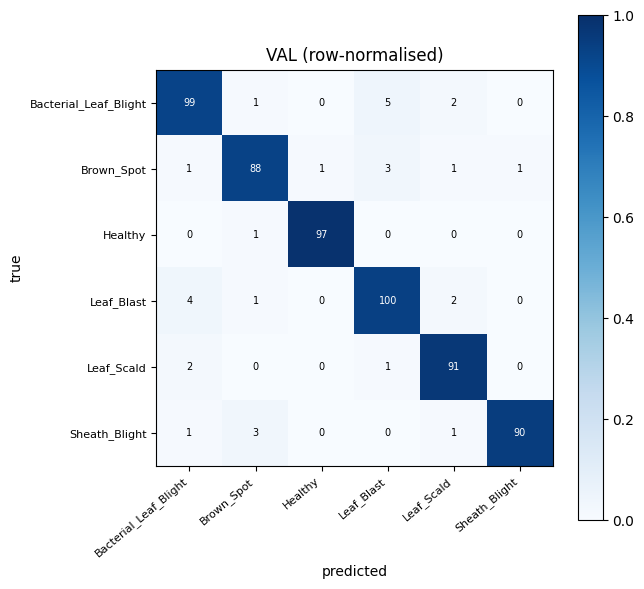

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



=== TEST ===
                class  support  precision  recall    f1
           Leaf_Scald       92      0.900   0.880 0.890
           Leaf_Blast      107      0.913   0.888 0.900
           Brown_Spot       97      0.936   0.907 0.921
Bacterial_Leaf_Blight      108      0.896   0.954 0.924
        Sheath_Blight       95      0.979   0.968 0.974
              Healthy       98      0.970   0.990 0.980
MACRO-F1 0.9315 | ACC 0.9313 | WORST-CLASS RECALL 0.8804


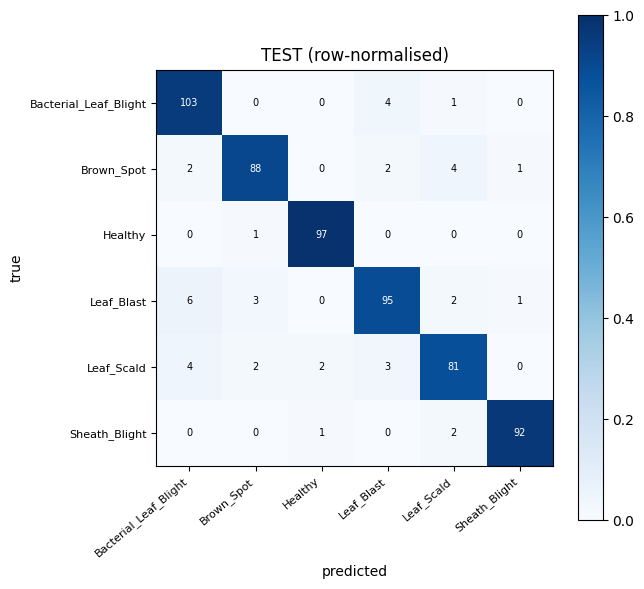


GAP (val - test macro-F1) = +0.0173
  > +0.05 : split still leaky or too small to trust
  <  0.00 : val was pessimistic, test is the better number

=== SOURCE-HELD-OUT EVAL ===  held-out source: dedeikh
shared classes: ['Bacterial_Leaf_Blight', 'Brown_Spot', 'Healthy', 'Leaf_Blast', 'Leaf_Scald'] (5 of 6)

held-out vs train D4 overlap (min over 8 D4 variants): 1.5% of 2628 held-out images within 4 bits of a train image (near-duplicate), 4.1% within 7 bits

=== SOURCE-HELD-OUT (dedeikh, 5 classes) ===
                class  support  precision  recall    f1
Bacterial_Leaf_Blight      438      0.053   0.027 0.036
           Leaf_Scald      438      0.611   0.176 0.273
           Brown_Spot      876      0.303   0.216 0.252
              Healthy      438      0.542   0.386 0.451
           Leaf_Blast      438      0.137   0.418 0.206
MACRO-F1 0.2436 | ACC 0.2397 | WORST-CLASS RECALL 0.0274


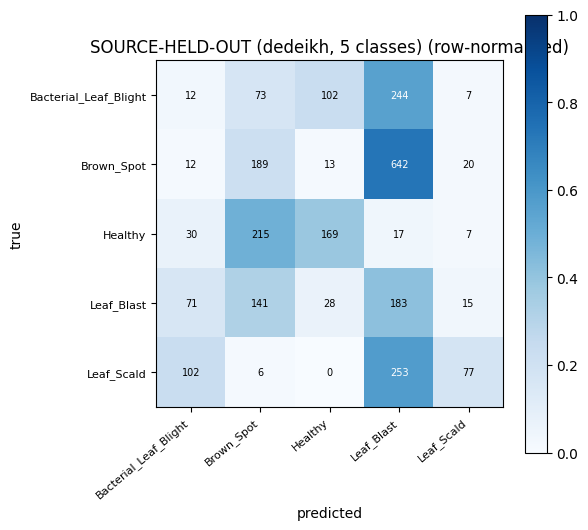

macro-F1 bootstrap 95% CI: [0.2265, 0.2599]

=== HELD-OUT with abstain@0.5 ===
                class  support  precision  recall    f1
Bacterial_Leaf_Blight      327      0.075   0.037 0.049
           Leaf_Scald      398      0.718   0.153 0.253
           Brown_Spot      798      0.338   0.201 0.252
              Healthy      294      0.550   0.429 0.482
           Leaf_Blast      344      0.135   0.477 0.211
MACRO-F1 0.2492 | ACC 0.2420 | WORST-CLASS RECALL 0.0367


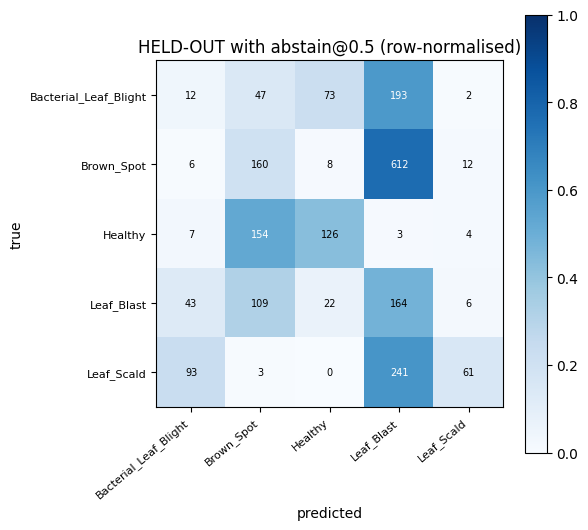

abstain@0.5: coverage 82.2% | acc on covered 0.2420 | macro-F1 on covered 0.2492

per-source macro-F1 (held-out set):
  dedeikh      n= 2628  macro-F1 0.2436

per-source macro-F1 (in-source TEST):
  anshul6      n=  565  macro-F1 0.9285
  indo3        n=   32  macro-F1 0.3200
  Brown_Spot: 20 images
  Leaf_Blast: 20 images
  Healthy: 20 images
crawl done in 81s -> /kaggle/working/field_crawl

=== FIELD STRESS TEST ===
      true          pred  conf  margin
Brown_Spot    Brown_Spot 0.490   0.093
Brown_Spot    Brown_Spot 0.989   0.984
Brown_Spot    Brown_Spot 0.955   0.916
Brown_Spot Sheath_Blight 0.575   0.332
Brown_Spot Sheath_Blight 0.756   0.518
Brown_Spot    Brown_Spot 1.000   1.000
Brown_Spot    Brown_Spot 0.720   0.439
Brown_Spot    Brown_Spot 0.993   0.987
Brown_Spot    Brown_Spot 0.989   0.979
Brown_Spot    Brown_Spot 0.997   0.996
Brown_Spot    Brown_Spot 0.654   0.326
Brown_Spot    Leaf_Blast 0.630   0.463
Brown_Spot       Healthy 0.987   0.980
Brown_Spot Sheath_Blight 0.394  

Model: "agrisense_infer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                   ┃ Output Shape                        ┃             Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)                     │ (1, 256, 256, 3)                    │                   0 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ resizing (Resizing)                            │ (1, 224, 224, 3)                    │                   0 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ agrisense_b0 (Functional)                      │ (1, 6)                              │           4,219,433 │
└────────────────────────────────────────────────┴─────────────────────────────────────┴─────────────────────┘

 Total params: 4,219,433 (16.10 MB)

 Trainable params: 4,174,850 (15.93 MB)

...

Saved artifact at '/tmp/tmp4xukmm0z'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 256, 256, 3), dtype=tf.float32, name='keras_tensor_2535')
Output Type:
  TensorSpec(shape=(1, 6), dtype=tf.float32, name=None)
Captures:
  139772984687888: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  139772984687120: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  139773782666192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139773782667920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139773782665232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139773782670608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139773782666384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139773782665616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139773782668304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139773782660816: TensorSpec(shape=(), dtype=tf.resource, name=None)

W0000 00:00:1791316053.720513      48 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1791316053.720570      48 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1791316053.925025      48 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


tflite 16.7 MB


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
2026-10-06 19:47:43.975372: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 19:47:44.111533: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 19:47:44.851032: E external/local_xla/xla/stream_executor/cuda/

PARITY keras-vs-tflite: 100% argmax agreement over 16 images at 256x256, max |delta prob| = 0.0000
bundle 31.1 MB — download from Kaggle Output, then attach it as a Dataset for future runs
total notebook wall clock 10.8 min
TFJS: separate notebook — pip install tensorflow==2.15.1 tensorflowjs numpy==1.26.4
freed input arrays; RAM available now 21.8 GB


In [19]:
# CELL 3 — RUN. Prints PIPELINE_VERSION and runs the whole pipeline.
run(CFG)

# Optional, after a full (non-smoke) run: evaluate the exported bundle on your own photos
# with agri/new/field_test.py (see README section 7.5).


In [27]:
# ============================================================
# CELL 5 — TEST the exported model (tflite bundle)
# ============================================================
import io, os, json, random, tempfile, zipfile
from pathlib import Path
import numpy as np
from PIL import Image, ImageOps
from IPython.display import display
import tensorflow as tf

BUNDLE = "/kaggle/working/agrisense_bundle.zip"      # same session as training
# BUNDLE = "/kaggle/input/datasets/<you>/<your-dataset>/agrisense_bundle.zip"

# Your own photos: a file path or a folder path. Leave "" to skip.
MY_PHOTOS = ""    # e.g. "/kaggle/input/datasets/<you>/my-leaves"
SHOW_IMAGES = True

# ---- load the bundle ----
if not os.path.exists(BUNDLE):
    raise FileNotFoundError(f"{BUNDLE} not found. If the session restarted, attach the bundle "
                            f"as a Dataset and point BUNDLE at it.")
tmp = tempfile.mkdtemp(prefix="agrisense_test_")
with zipfile.ZipFile(BUNDLE) as z:
    names = z.namelist()
    tfl = next(n for n in names if n.endswith(".tflite"))
    cj  = next(n for n in names if n.endswith("class_names.json"))
    z.extract(tfl, tmp); z.extract(cj, tmp)
contract = json.load(open(os.path.join(tmp, cj), encoding="utf-8"))
classes = contract["classes"]
abstain = float(contract.get("abstain_threshold", 0.5))

interp = tf.lite.Interpreter(model_path=os.path.join(tmp, tfl))
interp.allocate_tensors()
inp, out = interp.get_input_details()[0], interp.get_output_details()[0]
H, W = int(inp["shape"][1]), int(inp["shape"][2])
print(f"model input {H}x{W} float32 0-255 | classes: {classes} | abstain@{abstain}")

EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def predict_image(img, name, true=None, show=SHOW_IMAGES):
    img = ImageOps.exif_transpose(img).convert("RGB")      # phone photos: fix rotation
    if img.size != (W, H):
        img = img.resize((W, H), Image.LANCZOS)            # contract: high-quality resize
    x = np.asarray(img, dtype=np.float32)[None]            # 0-255, NEVER /255
    interp.set_tensor(inp["index"], x)
    interp.invoke()
    pr = interp.get_tensor(out["index"])[0].astype(np.float32)
    top = int(pr.argmax()); s = np.sort(pr)
    conf, margin = float(pr[top]), float(s[-1] - s[-2])
    flag = "ABSTAIN" if conf < abstain else "ok"
    tag = f"  (folder label: {true})" if true else ""
    print(f"\n{name}{tag}\n  -> {classes[top]}  conf {conf:.3f}  margin {margin:.3f}  [{flag}]")
    for i, c in enumerate(classes):
        print(f"     {c:<24} {pr[i]:.3f} {'#' * int(round(pr[i] * 30))}")
    if show:
        display(img)
    return classes[top], conf

# ---- 1) sanity test on held-out dedeikh images ----
roots = [p for pat in ("/kaggle/input/*/rice-leafs-disease-dataset",
                       "/kaggle/input/datasets/*/rice-leafs-disease-dataset",
                       "/kaggle/input/rice-leafs-disease-dataset")
         for p in map(str, Path("/").glob(pat.lstrip("/")))]
if roots:
    files = [p for p in Path(roots[0]).rglob("*") if p.suffix.lower() in EXT]
    random.seed(0)
    print(f"\n=== SANITY: 8 random images from {roots[0]} ===")
    hits = 0; sample = random.sample(files, min(8, len(files)))
    for p in sample:
        pred, _ = predict_image(Image.open(p), p.name, true=p.parent.name, show=False)
        hits += int(pred.lower().replace("_", "") == p.parent.name.lower().replace("_", ""))
    print(f"\nname-match {hits}/{len(sample)} (folders like narrow_brown_spot/tungro won't match by design)")

# ---- 2) your own photos (file or folder) ----
if MY_PHOTOS:
    p = Path(MY_PHOTOS)
    mine = [p] if p.is_file() else sorted(q for q in p.rglob("*") if q.suffix.lower() in EXT)
    print(f"\n=== YOUR PHOTOS: {len(mine)} ===")
    for q in mine:
        predict_image(Image.open(q), q.name)

# ---- 3) optional upload button (ipywidgets 7 AND 8) ----
try:
    from ipywidgets import FileUpload, Button, VBox, Output
    upload = FileUpload(accept="image/*", multiple=True, description="Choose photo(s)")
    btn = Button(description="Predict", button_style="primary")
    log = Output()

    def _files(w):
        v = w.value
        if isinstance(v, dict):                                    # ipywidgets 7
            return [(n, bytes(i["content"])) for n, i in v.items()]
        return [(f["name"], bytes(f["content"])) for f in v]       # ipywidgets 8

    def on_click(_):
        with log:
            log.clear_output()
            fs = _files(upload)
            if not fs:
                print("No photo selected. Click 'Choose photo(s)' first."); return
            for name, data in fs:
                predict_image(Image.open(io.BytesIO(data)), name)

    btn.on_click(on_click)
    display(VBox([upload, btn, log]))
except Exception as e:
    print(f"(upload widget unavailable here: {type(e).__name__}) - use MY_PHOTOS instead")

model input 256x256 float32 0-255 | classes: ['Bacterial_Leaf_Blight', 'Brown_Spot', 'Healthy', 'Leaf_Blast', 'Leaf_Scald', 'Sheath_Blight'] | abstain@0.5

=== SANITY: 8 random images from /kaggle/input/datasets/dedeikhsandwisaputra/rice-leafs-disease-dataset ===

leaf_scald (102).jpg  (folder label: leaf_scald)
  -> Bacterial_Leaf_Blight  conf 0.666  margin 0.381  [ok]
     Bacterial_Leaf_Blight    0.666 ####################
     Brown_Spot               0.002 
     Healthy                  0.002 
     Leaf_Blast               0.284 #########
     Leaf_Scald               0.045 #
     Sheath_Blight            0.000 

leaf_scald (347).jpg  (folder label: leaf_scald)
  -> Leaf_Blast  conf 0.743  margin 0.592  [ok]
     Bacterial_Leaf_Blight    0.091 ###
     Brown_Spot               0.014 
     Healthy                  0.000 
     Leaf_Blast               0.743 ######################
     Leaf_Scald               0.151 #####
     Sheath_Blight            0.000 

bacterial_leaf_blight (2